In [2]:
# ============================================================
# BLOCK 1 — Stage 0: Dataset Audit (Fresh Notebook, From Raw .mat)
# ============================================================

import os
import numpy as np
import pandas as pd
import scipy.io as sio
import pickle

FEATURE_DIR = "/kaggle/input/datasets/keshavagarwal03/eeg-seed-vig/EEG_Feature_5Bands/EEG_Feature_5Bands"
LABEL_DIR   = "/kaggle/input/datasets/keshavagarwal03/eeg-seed-vig/perclos_labels/perclos_labels"

feature_files = sorted([f for f in os.listdir(FEATURE_DIR) if f.endswith(".mat")])
label_files   = sorted([f for f in os.listdir(LABEL_DIR) if f.endswith(".mat")])

print(f"Feature files found: {len(feature_files)}")
print(f"Label files found:   {len(label_files)}")
print(f"Example feature file: {feature_files[0]}")
print(f"Example label file:   {label_files[0]}")

assert len(feature_files) == 23, f"Expected 23 feature files, got {len(feature_files)}"
assert len(label_files) == 23, f"Expected 23 label files, got {len(label_files)}"
assert set(feature_files) == set(label_files), "Filename mismatch between feature and label folders"


def extract_subject_id(filename):
    # e.g. "1_20151124_noon_2.mat" -> "1"
    return filename.split("_")[0]


def discretize_perclos(perclos_array):
    labels = np.zeros_like(perclos_array, dtype=int)
    labels[(perclos_array >= 0.35) & (perclos_array < 0.70)] = 1
    labels[perclos_array >= 0.70] = 2
    return labels


def compute_gt_trajectory_metrics(labels_discrete):
    diffs = np.diff(labels_discrete)
    decrease_rate = np.mean(diffs < 0)
    # Monotone deviation: L1 distance to nearest non-decreasing sequence, normalized
    iso_seq = np.maximum.accumulate(labels_discrete)
    monotone_deviation = np.mean(np.abs(labels_discrete - iso_seq)) / 2.0  # normalize by max class diff
    return decrease_rate, monotone_deviation


sessions = []
gt_rows = []

for fname in feature_files:
    subject_id = extract_subject_id(fname)
    session_id = fname.replace(".mat", "")

    feat_path = os.path.join(FEATURE_DIR, fname)
    label_path = os.path.join(LABEL_DIR, fname)

    feat_mat = sio.loadmat(feat_path)
    label_mat = sio.loadmat(label_path)

    de_lds = feat_mat["de_LDS"]          # (17, 885, 5)
    perclos = label_mat["perclos"].flatten().astype(np.float64)  # (885,)

    # Reshape: (17, 885, 5) -> (885, 17, 5) -> (885, 85)
    features = np.transpose(de_lds, (1, 0, 2))
    n_timesteps = features.shape[0]
    features = features.reshape(n_timesteps, -1)

    assert features.shape[1] == 85, f"Unexpected feature dim: {features.shape}"
    assert perclos.shape[0] == n_timesteps, f"Label/feature length mismatch in {fname}"

    labels_discrete = discretize_perclos(perclos)
    decrease_rate, monotone_dev = compute_gt_trajectory_metrics(labels_discrete)

    sessions.append({
        "subject_id": subject_id,
        "session_id": session_id,
        "features": features,
        "labels_raw": perclos,
        "labels_discrete": labels_discrete,
        "label_type": "continuous",
        "n_timesteps": n_timesteps
    })

    gt_rows.append({
        "subject_id": subject_id,
        "session_id": session_id,
        "n_timesteps": n_timesteps,
        "gt_decrease_rate": decrease_rate,
        "gt_monotone_deviation": monotone_dev
    })

gt_df = pd.DataFrame(gt_rows)

stage0_output = {
    "sessions": sessions,
    "gt_df": gt_df,
    "LABEL_TYPE": "continuous",
    "N_CHANNELS": 17,
    "N_FREQ_BANDS": 5
}

with open("/kaggle/working/stage0_output.pkl", "wb") as f:
    pickle.dump(stage0_output, f)

# --- Verification ---
print("\n--- Stage 0 Summary ---")
print(f"Total sessions: {len(sessions)}")
print(f"Unique subjects: {len(set(s['subject_id'] for s in sessions))}")
print(f"Total timesteps: {sum(s['n_timesteps'] for s in sessions)}")
print(f"Feature shape (session 0): {sessions[0]['features'].shape}")
print(f"Labels discrete shape (session 0): {sessions[0]['labels_discrete'].shape}")

all_labels = np.concatenate([s["labels_discrete"] for s in sessions])
print(f"\nClass distribution:")
for cls, name in enumerate(["Awake", "Tired", "Drowsy"]):
    pct = np.mean(all_labels == cls) * 100
    print(f"  {name} (Class {cls}): {pct:.1f}%")

print(f"\nMean GT decrease rate: {gt_df['gt_decrease_rate'].mean():.4f}")
print(f"Mean GT monotone deviation: {gt_df['gt_monotone_deviation'].mean():.4f}")
print(f"\nSaved to /kaggle/working/stage0_output.pkl")

Feature files found: 23
Label files found:   23
Example feature file: 10_20151125_noon.mat
Example label file:   10_20151125_noon.mat

--- Stage 0 Summary ---
Total sessions: 23
Unique subjects: 21
Total timesteps: 20355
Feature shape (session 0): (885, 85)
Labels discrete shape (session 0): (885,)

Class distribution:
  Awake (Class 0): 36.4%
  Tired (Class 1): 43.7%
  Drowsy (Class 2): 19.9%

Mean GT decrease rate: 0.0078
Mean GT monotone deviation: 0.3420

Saved to /kaggle/working/stage0_output.pkl


In [3]:
import os

# List everything under /kaggle/input to find the actual dataset folder name
for root, dirs, files in os.walk("/kaggle/input"):
    # Only print top 2-3 levels to avoid flooding output
    depth = root.count(os.sep) - "/kaggle/input".count(os.sep)
    if depth <= 2:
        print(root)
        for d in dirs:
            print("  [DIR]", d)
        for fname in files[:5]:
            print("  [FILE]", fname)

/kaggle/input
  [DIR] datasets
/kaggle/input/datasets
  [DIR] keshavagarwal03
/kaggle/input/datasets/keshavagarwal03
  [DIR] eeg-seed-vig


In [4]:
import os

base = "/kaggle/input/datasets/keshavagarwal03/eeg-seed-vig"
for root, dirs, files in os.walk(base):
    depth = root.count(os.sep) - base.count(os.sep)
    if depth <= 3:
        print(root)
        for d in dirs:
            print("  [DIR]", d)
        for fname in files[:5]:
            print("  [FILE]", fname)

/kaggle/input/datasets/keshavagarwal03/eeg-seed-vig
  [DIR] perclos_labels
  [DIR] EEG_Feature_5Bands
/kaggle/input/datasets/keshavagarwal03/eeg-seed-vig/perclos_labels
  [DIR] perclos_labels
/kaggle/input/datasets/keshavagarwal03/eeg-seed-vig/perclos_labels/perclos_labels
  [FILE] 20_20151129_night.mat
  [FILE] 3_20151024_noon.mat
  [FILE] 10_20151125_noon.mat
  [FILE] 6_20151121_noon.mat
  [FILE] 18_20150926_noon.mat
/kaggle/input/datasets/keshavagarwal03/eeg-seed-vig/EEG_Feature_5Bands
  [DIR] EEG_Feature_5Bands
/kaggle/input/datasets/keshavagarwal03/eeg-seed-vig/EEG_Feature_5Bands/EEG_Feature_5Bands
  [FILE] 20_20151129_night.mat
  [FILE] 3_20151024_noon.mat
  [FILE] 10_20151125_noon.mat
  [FILE] 6_20151121_noon.mat
  [FILE] 18_20150926_noon.mat


In [5]:
# ============================================================
# BLOCK 2 — Stage 1: GRU Classifier under LOSO
# ============================================================

import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
import pickle
import time

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# --- Load Stage 0 output ---
with open("/kaggle/working/stage0_output.pkl", "rb") as f:
    stage0 = pickle.load(f)

sessions = stage0["sessions"]


# --- Build subject -> session indices mapping (handles subj 4 and 5 with 2 sessions) ---
subject_groups = {}
for idx, s in enumerate(sessions):
    subject_groups.setdefault(s["subject_id"], []).append(idx)

subject_ids = sorted(subject_groups.keys(), key=lambda x: int(x))
print(f"Unique subjects: {len(subject_ids)}")
for sid in subject_ids:
    if len(subject_groups[sid]) > 1:
        print(f"  Subject {sid} has {len(subject_groups[sid])} sessions: "
              f"{[sessions[i]['session_id'] for i in subject_groups[sid]]}")


# --- GRU Classifier (identical to sanity-check version) ---
class GRUClassifier(nn.Module):
    def __init__(self, input_dim=85, hidden_dim=64, num_classes=3, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False
        )
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        out, _ = self.gru(x)
        logits = self.fc(out)
        return logits


def train_gru_on_fold(train_sessions, num_epochs=30, hidden_dim=64, lr=1e-3):
    """Train one GRU from scratch on all training sessions of this LOSO fold."""
    model = GRUClassifier(input_dim=85, hidden_dim=hidden_dim, num_classes=3).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()  # no class weighting, by design

    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        # Shuffle training session order each epoch (sequence content unchanged)
        order = np.random.permutation(len(train_sessions))
        for i in order:
            feat, lab = train_sessions[i]
            x = torch.tensor(feat, dtype=torch.float32).unsqueeze(0).to(device)   # (1, T, 85)
            y = torch.tensor(lab, dtype=torch.long).unsqueeze(0).to(device)       # (1, T)

            optimizer.zero_grad()
            logits = model(x)                      # (1, T, 3)
            loss = criterion(logits.view(-1, 3), y.view(-1))
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

    return model


def evaluate_gru_on_session(model, feat, lab):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(feat, dtype=torch.float32).unsqueeze(0).to(device)
        logits = model(x)                              # (1, T, 3)
        probs = torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy()   # (T, 3)
        preds = np.argmax(probs, axis=-1)                                # (T,)
    return preds, probs


# --- LOSO Loop ---
all_results = []
fold_accuracies = []

start_time = time.time()

for fold_num, test_subject in enumerate(subject_ids):
    test_indices = subject_groups[test_subject]
    train_indices = [i for i in range(len(sessions)) if i not in test_indices]

    # --- Fit StandardScaler on training data ONLY ---
    train_features_concat = np.concatenate([sessions[i]["features"] for i in train_indices], axis=0)
    scaler = StandardScaler()
    scaler.fit(train_features_concat)

    # --- Prepare scaled train sessions ---
    train_sessions_scaled = []
    for i in train_indices:
        feat_scaled = scaler.transform(sessions[i]["features"])
        lab = sessions[i]["labels_discrete"]
        train_sessions_scaled.append((feat_scaled, lab))

    # --- Train GRU for this fold ---
    model = train_gru_on_fold(train_sessions_scaled, num_epochs=30, hidden_dim=64, lr=1e-3)

    # --- Evaluate on held-out test session(s) ---
    for test_idx in test_indices:
        feat_scaled = scaler.transform(sessions[test_idx]["features"])
        lab = sessions[test_idx]["labels_discrete"]

        preds, probs = evaluate_gru_on_session(model, feat_scaled, lab)
        acc = np.mean(preds == lab)

        all_results.append({
            "subject_id": sessions[test_idx]["subject_id"],
            "session_id": sessions[test_idx]["session_id"],
            "y_true": lab,
            "y_pred": preds,
            "y_proba": probs,
            "accuracy": acc,
            "n_timesteps": len(lab)
        })
        fold_accuracies.append(acc)

    elapsed = time.time() - start_time
    print(f"Fold {fold_num+1}/{len(subject_ids)} | Test subject: {test_subject} | "
          f"Acc: {[f'{all_results[-1]['accuracy']:.3f}']} | Elapsed: {elapsed:.1f}s")

# --- Aggregate ---
y_all_true = np.concatenate([r["y_true"] for r in all_results])
y_all_pred = np.concatenate([r["y_pred"] for r in all_results])
overall_accuracy = np.mean(y_all_true == y_all_pred)

stage1_gru_output = {
    "all_results": all_results,
    "subject_ids": subject_ids,
    "subject_groups": subject_groups,
    "overall_accuracy": overall_accuracy,
    "y_all_true": y_all_true,
    "y_all_pred": y_all_pred
}

with open("/kaggle/working/stage1_gru_output.pkl", "wb") as f:
    pickle.dump(stage1_gru_output, f)

# --- Per-class recall ---
print("\n--- Stage 1 GRU Summary ---")
print(f"Overall LOSO accuracy: {overall_accuracy:.4f}")
print(f"Per-session accuracy: mean={np.mean(fold_accuracies):.4f}, std={np.std(fold_accuracies):.4f}")
print(f"Per-session accuracy range: {np.min(fold_accuracies):.4f} - {np.max(fold_accuracies):.4f}")

for cls, name in enumerate(["Awake", "Tired", "Drowsy"]):
    mask = y_all_true == cls
    recall = np.mean(y_all_pred[mask] == cls) if mask.sum() > 0 else float("nan")
    print(f"{name} recall: {recall:.3f}")

pred_classes_used = np.unique(y_all_pred)
print(f"\nUnique predicted classes overall: {pred_classes_used} (should be [0,1,2] — no collapse)")
print(f"\nSaved to /kaggle/working/stage1_gru_output.pkl")

Device: cuda
Unique subjects: 21
  Subject 4 has 2 sessions: ['4_20151105_noon', '4_20151107_noon']
  Subject 5 has 2 sessions: ['5_20141108_noon', '5_20151012_night']
Fold 1/21 | Test subject: 1 | Acc: ['0.626'] | Elapsed: 6.7s
Fold 2/21 | Test subject: 2 | Acc: ['0.867'] | Elapsed: 8.2s
Fold 3/21 | Test subject: 3 | Acc: ['0.211'] | Elapsed: 9.6s
Fold 4/21 | Test subject: 4 | Acc: ['0.598'] | Elapsed: 11.0s
Fold 5/21 | Test subject: 5 | Acc: ['0.477'] | Elapsed: 12.4s
Fold 6/21 | Test subject: 6 | Acc: ['0.551'] | Elapsed: 13.8s
Fold 7/21 | Test subject: 7 | Acc: ['0.111'] | Elapsed: 15.2s
Fold 8/21 | Test subject: 8 | Acc: ['0.182'] | Elapsed: 16.6s
Fold 9/21 | Test subject: 9 | Acc: ['0.533'] | Elapsed: 18.1s
Fold 10/21 | Test subject: 10 | Acc: ['0.290'] | Elapsed: 19.5s
Fold 11/21 | Test subject: 11 | Acc: ['0.359'] | Elapsed: 21.0s
Fold 12/21 | Test subject: 12 | Acc: ['0.371'] | Elapsed: 22.4s
Fold 13/21 | Test subject: 13 | Acc: ['0.868'] | Elapsed: 23.9s
Fold 14/21 | Test sub

In [6]:
# ============================================================
# BLOCK 3 — Stage 2: Temporal Inconsistency Metrics (GRU)
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, wilcoxon
import pickle

with open("/kaggle/working/stage1_gru_output.pkl", "rb") as f:
    stage1_gru = pickle.load(f)

all_results = stage1_gru["all_results"]


# --- Metric functions (identical definitions to MLP Stage 2) ---

def reversal_rate(seq):
    diffs = np.diff(seq)
    return np.mean(diffs < 0)

def temporal_deviation_score(seq):
    iso_seq = np.maximum.accumulate(seq)
    return np.mean(np.abs(seq - iso_seq)) / 2.0  # normalized by max class diff (0-2)

def trajectory_correlation(seq):
    t = np.arange(len(seq))
    corr, pval = spearmanr(t, seq)
    return corr, pval

def safety_critical_reversal_count(seq):
    # Drowsy(2) -> non-Drowsy transitions
    count = 0
    for i in range(len(seq) - 1):
        if seq[i] == 2 and seq[i+1] != 2:
            count += 1
    return count

def max_consecutive_inconsistency(seq):
    diffs = np.diff(seq)
    max_run = 0
    current_run = 0
    for d in diffs:
        if d < 0:
            current_run += 1
            max_run = max(max_run, current_run)
        else:
            current_run = 0
    return max_run


rows = []
for r in all_results:
    y_true = r["y_true"]
    y_pred = r["y_pred"]

    pred_rr = reversal_rate(y_pred)
    pred_tds = temporal_deviation_score(y_pred)
    pred_tc, pred_tc_p = trajectory_correlation(y_pred)
    pred_scrc_count = safety_critical_reversal_count(y_pred)
    pred_scrc_rate = pred_scrc_count / (len(y_pred) - 1)
    pred_mci = max_consecutive_inconsistency(y_pred)

    gt_rr = reversal_rate(y_true)
    gt_tds = temporal_deviation_score(y_true)
    gt_tc, gt_tc_p = trajectory_correlation(y_true)

    rows.append({
        "subject_id": r["subject_id"],
        "session_id": r["session_id"],
        "accuracy": r["accuracy"],
        "pred_reversal_rate": pred_rr,
        "pred_temporal_deviation_score": pred_tds,
        "pred_trajectory_correlation": pred_tc,
        "pred_tc_pvalue": pred_tc_p,
        "pred_scrc_rate": pred_scrc_rate,
        "pred_scrc_count": pred_scrc_count,
        "pred_max_consecutive_inconsistency": pred_mci,
        "gt_reversal_rate": gt_rr,
        "gt_tds": gt_tds,
        "gt_trajectory_correlation": gt_tc,
        "pred_excess_reversal_rate": pred_rr - gt_rr,
        "pred_excess_tds": pred_tds - gt_tds
    })

metrics_df = pd.DataFrame(rows)

# --- Statistical comparisons ---
wilcoxon_rr = wilcoxon(metrics_df["pred_reversal_rate"], metrics_df["gt_reversal_rate"])
accuracy_rr_corr = spearmanr(metrics_df["accuracy"], metrics_df["pred_reversal_rate"])

comparison_results = {
    "wilcoxon_rr_statistic": wilcoxon_rr.statistic,
    "wilcoxon_rr_pvalue": wilcoxon_rr.pvalue,
    "accuracy_rr_spearman_r": accuracy_rr_corr.correlation,
    "accuracy_rr_spearman_p": accuracy_rr_corr.pvalue
}

stage2_gru_output = {
    "metrics_df": metrics_df,
    "comparison_results": comparison_results
}

with open("/kaggle/working/stage2_gru_output.pkl", "wb") as f:
    pickle.dump(stage2_gru_output, f)

# --- Print summary ---
print("--- Stage 2 GRU Summary ---\n")
print(f"Mean pred reversal rate (GRU):  {metrics_df['pred_reversal_rate'].mean():.4f}")
print(f"Mean GT reversal rate:          {metrics_df['gt_reversal_rate'].mean():.4f}")
print(f"Mean pred trajectory corr (GRU): {metrics_df['pred_trajectory_correlation'].mean():.4f}")
print(f"Mean GT trajectory corr:         {metrics_df['gt_trajectory_correlation'].mean():.4f}")
print(f"Mean SCRC rate (GRU):            {metrics_df['pred_scrc_rate'].mean():.4f}")

print(f"\nWilcoxon signed-rank (pred RR vs GT RR): "
      f"stat={wilcoxon_rr.statistic:.2f}, p={wilcoxon_rr.pvalue:.6f}")
print(f"Spearman (accuracy vs reversal rate): "
      f"r={accuracy_rr_corr.correlation:.4f}, p={accuracy_rr_corr.pvalue:.4f}")

print(f"\nSaved to /kaggle/working/stage2_gru_output.pkl")

--- Stage 2 GRU Summary ---

Mean pred reversal rate (GRU):  0.0091
Mean GT reversal rate:          0.0078
Mean pred trajectory corr (GRU): 0.1177
Mean GT trajectory corr:         0.2037
Mean SCRC rate (GRU):            0.0051

Wilcoxon signed-rank (pred RR vs GT RR): stat=106.50, p=0.337440
Spearman (accuracy vs reversal rate): r=0.2324, p=0.2860

Saved to /kaggle/working/stage2_gru_output.pkl


/tmp/ipykernel_58/3765953712.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(t, seq)


In [7]:
# Diagnostic: which sessions triggered constant-prediction warning?
import numpy as np

constant_sessions = []
for r in all_results:
    if len(np.unique(r["y_pred"])) == 1:
        constant_sessions.append((r["subject_id"], r["session_id"], r["y_pred"][0], r["accuracy"]))

print(f"Sessions with constant GRU predictions: {len(constant_sessions)}")
for s in constant_sessions:
    print(f"  Subject {s[0]}, session {s[1]}: predicted class {s[2]} throughout, accuracy={s[3]:.3f}")

# Also check NaN count in trajectory correlation column
nan_count = metrics_df["pred_trajectory_correlation"].isna().sum()
print(f"\nNaN trajectory correlations in metrics_df: {nan_count}")

Sessions with constant GRU predictions: 2
  Subject 2, session 2_20151106_noon: predicted class 0 throughout, accuracy=0.867
  Subject 5, session 5_20151012_night: predicted class 0 throughout, accuracy=0.477

NaN trajectory correlations in metrics_df: 2


In [8]:
# ============================================================
# BLOCK 3b — Flag collapsed sessions, recompute GRU summary stats
# ============================================================

import numpy as np

# Identify collapsed sessions (already found: subject 2, subject 5_night)
collapsed_session_ids = {s[1] for s in constant_sessions}  # from previous check
print(f"Collapsed sessions (single-class prediction): {collapsed_session_ids}")

# Mark in metrics_df
metrics_df["is_collapsed"] = metrics_df["session_id"].isin(collapsed_session_ids)

# Full vs non-collapsed comparison (within GRU only)
print("\n--- Reversal Rate ---")
print(f"All 23 sessions:        {metrics_df['pred_reversal_rate'].mean():.4f}")
print(f"Excl. collapsed (n=21): {metrics_df.loc[~metrics_df['is_collapsed'], 'pred_reversal_rate'].mean():.4f}")

print("\n--- SCRC rate ---")
print(f"All 23 sessions:        {metrics_df['pred_scrc_rate'].mean():.4f}")
print(f"Excl. collapsed (n=21): {metrics_df.loc[~metrics_df['is_collapsed'], 'pred_scrc_rate'].mean():.4f}")

print("\n--- Trajectory correlation (NaNs already excluded by pandas) ---")
print(f"Mean (n=21, valid only): {metrics_df['pred_trajectory_correlation'].mean():.4f}")

print(f"\nCollapse rate: {metrics_df['is_collapsed'].sum()}/23 sessions ({metrics_df['is_collapsed'].mean()*100:.1f}%)")

# Save updated metrics_df with collapse flag back into stage2 output
stage2_gru_output["metrics_df"] = metrics_df
with open("/kaggle/working/stage2_gru_output.pkl", "wb") as f:
    pickle.dump(stage2_gru_output, f)

print("\nUpdated stage2_gru_output.pkl saved with is_collapsed flag.")

Collapsed sessions (single-class prediction): {'2_20151106_noon', '5_20151012_night'}

--- Reversal Rate ---
All 23 sessions:        0.0091
Excl. collapsed (n=21): 0.0100

--- SCRC rate ---
All 23 sessions:        0.0051
Excl. collapsed (n=21): 0.0056

--- Trajectory correlation (NaNs already excluded by pandas) ---
Mean (n=21, valid only): 0.1177

Collapse rate: 2/23 sessions (8.7%)

Updated stage2_gru_output.pkl saved with is_collapsed flag.


In [9]:
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.8 MB/s eta 0:00:0000:01


In [10]:
# ============================================================
# BLOCK 4 — Stage 3: Survivability Test (GRU)
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import mode
import pickle

with open("/kaggle/working/stage1_gru_output.pkl", "rb") as f:
    stage1_gru = pickle.load(f)

with open("/kaggle/working/stage2_gru_output.pkl", "rb") as f:
    stage2_gru = pickle.load(f)

all_results = stage1_gru["all_results"]


# --- Reuse metric functions (identical to Stage 2) ---
def reversal_rate(seq):
    diffs = np.diff(seq)
    return np.mean(diffs < 0)

def temporal_deviation_score(seq):
    iso_seq = np.maximum.accumulate(seq)
    return np.mean(np.abs(seq - iso_seq)) / 2.0


# --- Post-processing methods ---
def majority_vote_smooth(seq, window):
    n = len(seq)
    smoothed = np.zeros_like(seq)
    half = window // 2
    for i in range(n):
        lo = max(0, i - half)
        hi = min(n, i + half + 1)
        window_vals = seq[lo:hi]
        smoothed[i] = mode(window_vals, keepdims=False).mode
    return smoothed

def moving_average_smooth(seq, window):
    n = len(seq)
    smoothed = np.zeros_like(seq)
    half = window // 2
    for i in range(n):
        lo = max(0, i - half)
        hi = min(n, i + half + 1)
        smoothed[i] = int(round(np.mean(seq[lo:hi])))
    return np.clip(smoothed, 0, 2)


# --- HMM Viterbi (left-to-right, trained on training sessions' label transitions) ---
try:
    from hmmlearn import hmm
    HMM_AVAILABLE = True
except ImportError:
    HMM_AVAILABLE = False
    print("WARNING: hmmlearn not available, skipping HMM method")


def train_lr_hmm(train_label_seqs, n_states=3):
    """Train a left-to-right (no backward transitions) categorical HMM on label sequences."""
    model = hmm.CategoricalHMM(n_components=n_states, init_params="", n_iter=50, random_state=42)
    # Left-to-right transition matrix: can stay or move forward only
    A = np.zeros((n_states, n_states))
    for i in range(n_states):
        if i < n_states - 1:
            A[i, i] = 0.9
            A[i, i+1] = 0.1
        else:
            A[i, i] = 1.0
    model.transmat_ = A
    model.startprob_ = np.array([1.0, 0.0, 0.0])  # sessions start Awake
    # Emission probs: estimate from training data empirically (identity-ish, since input IS the state)
    emissionprob = np.eye(n_states) * 0.8 + (np.ones((n_states, n_states)) - np.eye(n_states)) * 0.1
    model.emissionprob_ = emissionprob
    return model


def hmm_decode(model, seq):
    seq_reshaped = np.array(seq).reshape(-1, 1)
    _, decoded = model.decode(seq_reshaped, algorithm="viterbi")
    return decoded


# --- Run survivability test per session ---
pp_rows = []

if HMM_AVAILABLE:
    # Train one LR-HMM globally (uses fixed left-to-right structure, not data-fit transitions)
    hmm_model = train_lr_hmm(None, n_states=3)

for r in all_results:
    y_pred = r["y_pred"]
    raw_rr = reversal_rate(y_pred)
    raw_tds = temporal_deviation_score(y_pred)

    row = {
        "subject_id": r["subject_id"],
        "session_id": r["session_id"],
        "raw_rr": raw_rr,
        "raw_tds": raw_tds,
        "raw_accuracy": r["accuracy"]
    }

    for w in [3, 5, 9]:
        mv = majority_vote_smooth(y_pred, w)
        row[f"mv{w}_rr"] = reversal_rate(mv)
        row[f"mv{w}_acc"] = np.mean(mv == r["y_true"])

        ma = moving_average_smooth(y_pred, w)
        row[f"ma{w}_rr"] = reversal_rate(ma)
        row[f"ma{w}_acc"] = np.mean(ma == r["y_true"])

    if HMM_AVAILABLE:
        try:
            hmm_pred = hmm_decode(hmm_model, y_pred)
            row["hmm_rr"] = reversal_rate(hmm_pred)
            row["hmm_acc"] = np.mean(hmm_pred == r["y_true"])
        except Exception as e:
            row["hmm_rr"] = np.nan
            row["hmm_acc"] = np.nan

    pp_rows.append(row)

pp_df = pd.DataFrame(pp_rows)

raw_rr_mean = pp_df["raw_rr"].mean()
pp_methods = ["mv3_rr", "mv5_rr", "mv9_rr", "ma3_rr", "ma5_rr", "ma9_rr"]
if HMM_AVAILABLE:
    pp_methods.append("hmm_rr")

best_method = min(pp_methods, key=lambda m: pp_df[m].mean())
best_rr_after_pp = pp_df[best_method].mean()
rr_reduction_pct = (raw_rr_mean - best_rr_after_pp) / raw_rr_mean * 100

stage3_gru_output = {
    "pp_df": pp_df,
    "raw_rr": raw_rr_mean,
    "best_rr_after_pp": best_rr_after_pp,
    "best_method": best_method,
    "rr_reduction_pct": rr_reduction_pct
}

with open("/kaggle/working/stage3_gru_output.pkl", "wb") as f:
    pickle.dump(stage3_gru_output, f)

# --- Print summary ---
print("--- Stage 3 GRU Survivability Summary ---\n")
print(f"Raw GRU reversal rate:        {raw_rr_mean:.4f}")
print(f"Raw GRU accuracy:             {pp_df['raw_accuracy'].mean():.4f}\n")

for m in pp_methods:
    acc_col = m.replace("_rr", "_acc")
    print(f"{m:10s}: RR={pp_df[m].mean():.4f}, Acc={pp_df[acc_col].mean():.4f}")

print(f"\nBest method: {best_method}")
print(f"Best RR after post-processing: {best_rr_after_pp:.4f}")
print(f"RR reduction: {rr_reduction_pct:.2f}%")

print(f"\nSaved to /kaggle/working/stage3_gru_output.pkl")

--- Stage 3 GRU Survivability Summary ---

Raw GRU reversal rate:        0.0091
Raw GRU accuracy:             0.4242

mv3_rr    : RR=0.0083, Acc=0.4242
mv5_rr    : RR=0.0080, Acc=0.4245
mv9_rr    : RR=0.0063, Acc=0.4227
ma3_rr    : RR=0.0093, Acc=0.4254
ma5_rr    : RR=0.0088, Acc=0.4258
ma9_rr    : RR=0.0073, Acc=0.4266
hmm_rr    : RR=0.0000, Acc=0.3487

Best method: hmm_rr
Best RR after post-processing: 0.0000
RR reduction: 100.00%

Saved to /kaggle/working/stage3_gru_output.pkl


In [11]:
# ============================================================
# BLOCK 4b — Correct survivability conclusion (exclude HMM from "best naive" claim)
# ============================================================

naive_methods = ["mv3_rr", "mv5_rr", "mv9_rr", "ma3_rr", "ma5_rr", "ma9_rr"]  # HMM excluded — wins trivially by construction

best_naive_method = min(naive_methods, key=lambda m: pp_df[m].mean())
best_naive_rr = pp_df[best_naive_method].mean()
best_naive_acc = pp_df[best_naive_method.replace("_rr", "_acc")].mean()
naive_rr_reduction_pct = (raw_rr_mean - best_naive_rr) / raw_rr_mean * 100

print(f"Best NAIVE (non-degenerate) method: {best_naive_method}")
print(f"RR: {best_naive_rr:.4f} (reduction: {naive_rr_reduction_pct:.2f}%)")
print(f"Accuracy: {best_naive_acc:.4f} (raw was {raw_rr_mean:.4f}... wait, compare to raw_accuracy)")
print(f"Accuracy change: {best_naive_acc - pp_df['raw_accuracy'].mean():+.4f}")

print(f"\nHMM result (reported separately, NOT as 'best'): RR=0.0000 (trivial, by construction), "
      f"Acc={pp_df['hmm_acc'].mean():.4f} (cost: {pp_df['hmm_acc'].mean() - pp_df['raw_accuracy'].mean():+.4f})")

# Update saved output with corrected conclusion
stage3_gru_output["best_naive_method"] = best_naive_method
stage3_gru_output["best_naive_rr"] = best_naive_rr
stage3_gru_output["naive_rr_reduction_pct"] = naive_rr_reduction_pct
stage3_gru_output["hmm_excluded_reason"] = "Left-to-right HMM trivially achieves RR=0 by construction (cannot predict reversals), at severe accuracy cost. Not a genuine survivability result."

with open("/kaggle/working/stage3_gru_output.pkl", "wb") as f:
    pickle.dump(stage3_gru_output, f)

print("\nCorrected stage3_gru_output.pkl saved.")

Best NAIVE (non-degenerate) method: mv9_rr
RR: 0.0063 (reduction: 30.27%)
Accuracy: 0.4227 (raw was 0.0091... wait, compare to raw_accuracy)
Accuracy change: -0.0015

HMM result (reported separately, NOT as 'best'): RR=0.0000 (trivial, by construction), Acc=0.3487 (cost: -0.0755)

Corrected stage3_gru_output.pkl saved.


In [12]:
# ============================================================
# CORRECTED BLOCK — Stage 2: Temporal Metrics (exact MLP functions)
# ============================================================

import numpy as np
import pandas as pd
import pickle
from scipy.stats import spearmanr, wilcoxon
from sklearn.isotonic import IsotonicRegression

with open("/kaggle/working/stage1_gru_output.pkl", "rb") as f:
    stage1_gru = pickle.load(f)

all_results = stage1_gru["all_results"]


# --- EXACT MLP FUNCTIONS (copied verbatim) ---

def nearest_monotone_nondecreasing(seq):
    ir = IsotonicRegression(increasing=True)
    t = np.arange(len(seq))
    return ir.fit_transform(t, seq.astype(float))


def compute_temporal_metrics(pred_sequence, gt_sequence=None):
    pred = np.array(pred_sequence)
    T = len(pred)
    if T < 5:
        return None

    diffs = np.diff(pred)
    rr = (diffs < 0).mean()

    nearest_mono = nearest_monotone_nondecreasing(pred)
    tds = np.mean(np.abs(pred.astype(float) - nearest_mono)) / 2.0

    tc, tc_pval = spearmanr(np.arange(T), pred)

    scrc_total = 0
    for i in range(len(pred) - 1):
        if pred[i] == 2 and pred[i+1] < 2:
            scrc_total += 1
    scrc_rate = scrc_total / T

    max_dec_run = 0
    cur_dec_run = 0
    for d in diffs:
        if d < 0:
            cur_dec_run += 1
            max_dec_run = max(max_dec_run, cur_dec_run)
        else:
            cur_dec_run = 0

    result = {
        "reversal_rate": rr,
        "temporal_deviation_score": tds,
        "trajectory_correlation": tc,
        "tc_pvalue": tc_pval,
        "scrc_rate": scrc_rate,
        "scrc_count": scrc_total,
        "max_consecutive_inconsistency": max_dec_run,
        "n_timesteps": T,
    }

    if gt_sequence is not None:
        gt = np.array(gt_sequence)
        gt_diffs = np.diff(gt)
        gt_rr = (gt_diffs < 0).mean()
        gt_nearest_mono = nearest_monotone_nondecreasing(gt)
        gt_tds = np.mean(np.abs(gt.astype(float) - gt_nearest_mono)) / 2.0
        gt_tc, _ = spearmanr(np.arange(len(gt)), gt)

        result["excess_reversal_rate"] = max(0, rr - gt_rr)
        result["excess_tds"] = max(0, tds - gt_tds)
        result["gt_reversal_rate"] = gt_rr
        result["gt_tds"] = gt_tds
        result["gt_trajectory_correlation"] = gt_tc

    return result


# --- Compute metrics on all sessions (exact MLP Block 2.2 logic) ---
session_metrics = []

for result in all_results:
    y_pred = result["y_pred"]
    y_true = result["y_true"]

    pred_metrics = compute_temporal_metrics(y_pred, y_true)
    if pred_metrics is None:
        continue

    gt_metrics_local = compute_temporal_metrics(y_true)

    entry = {
        "subject_id": result["subject_id"],
        "session_id": result["session_id"],
        "accuracy": result["accuracy"],
        "n_timesteps": result["n_timesteps"],
    }
    for k, v in pred_metrics.items():
        entry[f"pred_{k}"] = v
    for k, v in gt_metrics_local.items():
        entry[f"gt_{k}"] = v

    session_metrics.append(entry)

metrics_df = pd.DataFrame(session_metrics)
print(f"Computed metrics for {len(metrics_df)} sessions")


# --- Core comparison: exact MLP Block 2.3 logic (one-sided Wilcoxon, all 3 metrics) ---

metrics_to_compare = [
    ("reversal_rate", "Reversal Rate", "Higher = more inconsistency. Bad."),
    ("temporal_deviation_score", "Temporal Deviation Score", "Higher = further from smooth. Bad."),
    ("trajectory_correlation", "Trajectory Correlation", "Higher = better temporal trend. Good."),
]

comparison_results = {}

print("=" * 60)
print("CORRECTED CORE COMPARISON: GRU MODEL vs GROUND TRUTH")
print("=" * 60)

for metric_key, metric_name, interpretation in metrics_to_compare:
    pred_vals = metrics_df[f"pred_{metric_key}"].dropna().values
    gt_vals = metrics_df[f"gt_{metric_key}"].dropna().values

    n = min(len(pred_vals), len(gt_vals))
    pred_vals = pred_vals[:n]
    gt_vals = gt_vals[:n]

    if metric_key == "trajectory_correlation":
        try:
            stat, pval = wilcoxon(gt_vals, pred_vals, alternative="greater")
        except Exception:
            stat, pval = float("nan"), float("nan")
        direction = "GT > Model (model lacks temporal trend)"
    else:
        try:
            stat, pval = wilcoxon(pred_vals, gt_vals, alternative="greater")
        except Exception:
            stat, pval = float("nan"), float("nan")
        direction = "Model > GT (model adds inconsistency)"

    mean_pred = np.nanmean(pred_vals)
    mean_gt = np.nanmean(gt_vals)
    effect = mean_pred - mean_gt

    comparison_results[metric_key] = {
        "mean_pred": mean_pred, "mean_gt": mean_gt,
        "effect": effect, "pval": pval, "stat": stat
    }

    print(f"\n{metric_name} ({interpretation})")
    print(f"  Model (GRU): {mean_pred:.4f} ± {np.nanstd(pred_vals):.4f}")
    print(f"  Ground truth: {mean_gt:.4f} ± {np.nanstd(gt_vals):.4f}")
    print(f"  Difference: {effect:+.4f}")
    print(f"  Wilcoxon p-value: {pval:.4f}  ({direction})")
    if not np.isnan(pval):
        if pval < 0.05:
            print(f"  -> SIGNIFICANT")
        elif pval < 0.10:
            print(f"  ~ MARGINAL")
        else:
            print(f"  -> NOT SIGNIFICANT")

# Accuracy vs RR independence check (unchanged logic, kept for continuity)
corr, pval_corr = spearmanr(metrics_df["accuracy"], metrics_df["pred_reversal_rate"])
print(f"\nAccuracy vs Reversal Rate: Spearman r={corr:.4f}, p={pval_corr:.4f}")

pred_scrc = metrics_df["pred_scrc_rate"].mean()
print(f"\nSafety-critical reversal rate (GRU): {pred_scrc:.4f}")

stage2_gru_output_corrected = {
    "metrics_df": metrics_df,
    "comparison_results": comparison_results,
    "accuracy_rr_spearman_r": corr,
    "accuracy_rr_spearman_p": pval_corr,
}

with open("/kaggle/working/stage2_gru_output.pkl", "wb") as f:
    pickle.dump(stage2_gru_output_corrected, f)

print("\nSaved corrected stage2_gru_output.pkl")

Computed metrics for 23 sessions
CORRECTED CORE COMPARISON: GRU MODEL vs GROUND TRUTH

Reversal Rate (Higher = more inconsistency. Bad.)
  Model (GRU): 0.0091 ± 0.0067
  Ground truth: 0.0078 ± 0.0041
  Difference: +0.0013
  Wilcoxon p-value: 0.1687  (Model > GT (model adds inconsistency))
  -> NOT SIGNIFICANT

Temporal Deviation Score (Higher = further from smooth. Bad.)
  Model (GRU): 0.1412 ± 0.1194
  Ground truth: 0.1874 ± 0.1013
  Difference: -0.0462
  Wilcoxon p-value: 0.9288  (Model > GT (model adds inconsistency))
  -> NOT SIGNIFICANT

Trajectory Correlation (Higher = better temporal trend. Good.)
  Model (GRU): 0.1177 ± 0.2756
  Ground truth: 0.2338 ± 0.3072
  Difference: -0.1161
  Wilcoxon p-value: 0.1078  (GT > Model (model lacks temporal trend))
  -> NOT SIGNIFICANT

Accuracy vs Reversal Rate: Spearman r=0.2324, p=0.2860

Safety-critical reversal rate (GRU): 0.0051

Saved corrected stage2_gru_output.pkl


/tmp/ipykernel_58/3811263469.py:37: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  tc, tc_pval = spearmanr(np.arange(T), pred)
/tmp/ipykernel_58/3811263469.py:37: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  tc, tc_pval = spearmanr(np.arange(T), pred)


In [13]:
# ============================================================
# CORRECTED BLOCK — Stage 3: Survivability (exact MLP functions, incl. real HMM)
# ============================================================

import numpy as np
import pandas as pd
import pickle
from scipy.stats import mode
from scipy.ndimage import uniform_filter1d
from sklearn.metrics import accuracy_score
from hmmlearn import hmm

with open("/kaggle/working/stage1_gru_output.pkl", "rb") as f:
    stage1_gru = pickle.load(f)
with open("/kaggle/working/stage2_gru_output.pkl", "rb") as f:
    stage2_gru = pickle.load(f)

all_results = stage1_gru["all_results"]
metrics_df = stage2_gru["metrics_df"]


# --- EXACT MLP post-processing functions ---

def majority_vote_smooth(predictions, window_size=5):
    smoothed = np.array(predictions, dtype=int)
    half = window_size // 2
    for i in range(len(predictions)):
        start = max(0, i - half)
        end = min(len(predictions), i + half + 1)
        window = predictions[start:end]
        m = mode(window, keepdims=True)
        smoothed[i] = int(m.mode[0])
    return smoothed


def moving_average_smooth(predictions, window_size=5):
    pred_float = predictions.astype(float)
    smoothed_float = uniform_filter1d(pred_float, size=window_size, mode="nearest")
    smoothed = np.clip(np.round(smoothed_float), 0, 2).astype(int)
    return smoothed


def fit_hmm_and_decode(all_train_results, test_result, n_components=3, n_iter=50):
    try:
        train_sequences = []
        train_lengths = []
        for r in all_train_results:
            seq = r["y_pred"].reshape(-1, 1)
            train_sequences.append(seq)
            train_lengths.append(len(seq))

        X_train = np.vstack(train_sequences)

        model = hmm.CategoricalHMM(n_components=n_components, n_iter=n_iter, random_state=42)
        model.startprob_ = np.array([0.7, 0.2, 0.1])
        model.transmat_ = np.array([
            [0.85, 0.13, 0.02],
            [0.05, 0.85, 0.10],
            [0.02, 0.08, 0.90],
        ])

        model.fit(X_train, train_lengths)

        test_obs = test_result["y_pred"].reshape(-1, 1)
        log_prob, decoded = model.decode(test_obs, algorithm="viterbi")

        return decoded, True

    except Exception as e:
        print(f"  HMM failed: {e}, using majority vote fallback")
        return majority_vote_smooth(test_result["y_pred"], window_size=7), False


# --- Re-use compute_temporal_metrics from corrected Stage 2 (must be in scope) ---
from sklearn.isotonic import IsotonicRegression
from scipy.stats import spearmanr

def nearest_monotone_nondecreasing(seq):
    ir = IsotonicRegression(increasing=True)
    t = np.arange(len(seq))
    return ir.fit_transform(t, seq.astype(float))

def compute_temporal_metrics(pred_sequence, gt_sequence=None):
    pred = np.array(pred_sequence)
    T = len(pred)
    if T < 5:
        return None
    diffs = np.diff(pred)
    rr = (diffs < 0).mean()
    nearest_mono = nearest_monotone_nondecreasing(pred)
    tds = np.mean(np.abs(pred.astype(float) - nearest_mono)) / 2.0
    tc, tc_pval = spearmanr(np.arange(T), pred)
    scrc_total = 0
    for i in range(len(pred) - 1):
        if pred[i] == 2 and pred[i+1] < 2:
            scrc_total += 1
    scrc_rate = scrc_total / T
    result = {
        "reversal_rate": rr, "temporal_deviation_score": tds,
        "trajectory_correlation": tc, "tc_pvalue": tc_pval,
        "scrc_rate": scrc_rate, "scrc_count": scrc_total, "n_timesteps": T,
    }
    if gt_sequence is not None:
        gt = np.array(gt_sequence)
        gt_diffs = np.diff(gt)
        gt_rr = (gt_diffs < 0).mean()
        gt_nearest_mono = nearest_monotone_nondecreasing(gt)
        gt_tds = np.mean(np.abs(gt.astype(float) - gt_nearest_mono)) / 2.0
        gt_tc, _ = spearmanr(np.arange(len(gt)), gt)
        result["gt_reversal_rate"] = gt_rr
        result["gt_tds"] = gt_tds
        result["gt_trajectory_correlation"] = gt_tc
        result["excess_reversal_rate"] = max(0, rr - gt_rr)
    return result


# --- Apply all post-processing (exact MLP Block 3.5 logic) ---
print("Applying post-processing to all GRU test sessions...")

postproc_results = []
window_sizes = [3, 5, 9]

for i, result in enumerate(all_results):
    y_pred = result["y_pred"]
    y_true = result["y_true"]

    entry = {
        "subject_id": result["subject_id"],
        "session_id": result["session_id"],
        "acc_raw": result["accuracy"],
        "n_timesteps": len(y_true),
    }

    for w in window_sizes:
        smoothed_mv = majority_vote_smooth(y_pred, w)
        smoothed_ma = moving_average_smooth(y_pred, w)

        metrics_mv = compute_temporal_metrics(smoothed_mv, y_true)
        metrics_ma = compute_temporal_metrics(smoothed_ma, y_true)

        acc_mv = accuracy_score(y_true, smoothed_mv)
        acc_ma = accuracy_score(y_true, smoothed_ma)

        entry[f"rr_mv_w{w}"] = metrics_mv["reversal_rate"]
        entry[f"rr_ma_w{w}"] = metrics_ma["reversal_rate"]
        entry[f"acc_mv_w{w}"] = acc_mv
        entry[f"acc_ma_w{w}"] = acc_ma
        entry[f"tds_mv_w{w}"] = metrics_mv["temporal_deviation_score"]
        entry[f"tds_ma_w{w}"] = metrics_ma["temporal_deviation_score"]
        entry[f"tc_mv_w{w}"] = metrics_mv["trajectory_correlation"]
        entry[f"tc_ma_w{w}"] = metrics_ma["trajectory_correlation"]

    train_results_for_hmm = [r for r in all_results if r["subject_id"] != result["subject_id"]]

    if len(train_results_for_hmm) > 5:
        decoded_hmm, hmm_success = fit_hmm_and_decode(train_results_for_hmm, result)
        metrics_hmm = compute_temporal_metrics(decoded_hmm, y_true)
        acc_hmm = accuracy_score(y_true, decoded_hmm)

        entry["rr_hmm"] = metrics_hmm["reversal_rate"]
        entry["acc_hmm"] = acc_hmm
        entry["tds_hmm"] = metrics_hmm["temporal_deviation_score"]
        entry["tc_hmm"] = metrics_hmm["trajectory_correlation"]
        entry["hmm_success"] = hmm_success
    else:
        entry["rr_hmm"] = np.nan
        entry["acc_hmm"] = np.nan
        entry["tds_hmm"] = np.nan
        entry["tc_hmm"] = np.nan

    postproc_results.append(entry)

    if (i + 1) % 5 == 0:
        print(f"  Processed {i+1}/{len(all_results)} sessions")

pp_df = pd.DataFrame(postproc_results)
print(f"\nCompleted processing {len(pp_df)} sessions.")


# --- Survivability table (exact MLP Block 3.6 logic) ---
raw_rr = metrics_df["pred_reversal_rate"].mean()
raw_tds = metrics_df["pred_temporal_deviation_score"].mean()
raw_tc = metrics_df["pred_trajectory_correlation"].mean()
raw_acc = pp_df["acc_raw"].mean()

print("=" * 65)
print("CORRECTED SURVIVABILITY TABLE (GRU)")
print("=" * 65)
print(f"\n{'Method':<25} {'Acc':>6} {'RR':>8} {'TDS':>8} {'TC':>8} {'RR_red%':>8}")
print("-" * 65)
print(f"{'Raw (no post-proc)':<25} {raw_acc:>6.3f} {raw_rr:>8.4f} {raw_tds:>8.4f} {raw_tc:>8.4f} {'—':>8}")

methods = [
    ("Majority Vote w=3", "acc_mv_w3", "rr_mv_w3", "tds_mv_w3", "tc_mv_w3"),
    ("Majority Vote w=5", "acc_mv_w5", "rr_mv_w5", "tds_mv_w5", "tc_mv_w5"),
    ("Majority Vote w=9", "acc_mv_w9", "rr_mv_w9", "tds_mv_w9", "tc_mv_w9"),
    ("Moving Avg w=3", "acc_ma_w3", "rr_ma_w3", "tds_ma_w3", "tc_ma_w3"),
    ("Moving Avg w=5", "acc_ma_w5", "rr_ma_w5", "tds_ma_w5", "tc_ma_w5"),
    ("Moving Avg w=9", "acc_ma_w9", "rr_ma_w9", "tds_ma_w9", "tc_ma_w9"),
    ("HMM Viterbi", "acc_hmm", "rr_hmm", "tds_hmm", "tc_hmm"),
]

for method_name, acc_col, rr_col, tds_col, tc_col in methods:
    if rr_col not in pp_df.columns:
        continue
    acc_m = pp_df[acc_col].mean()
    rr_m = pp_df[rr_col].mean()
    tds_m = pp_df[tds_col].mean()
    tc_m = pp_df[tc_col].mean()
    rr_reduction = 100 * (raw_rr - rr_m) / (raw_rr + 1e-9)
    acc_delta = acc_m - raw_acc

    flag = ""
    if rr_reduction > 60 and abs(acc_delta) < 0.02:
        flag = "<- post-proc solves it"
    elif rr_reduction > 40 and acc_delta < -0.04:
        flag = "<- consistency/accuracy tradeoff"
    elif rr_reduction < 20:
        flag = "<- inconsistency persists"

    print(f"{method_name:<25} {acc_m:>6.3f} {rr_m:>8.4f} {tds_m:>8.4f} "
          f"{tc_m:>8.4f} {rr_reduction:>7.1f}%  {flag}")

best_rr_after_pp = min(
    [pp_df[f"rr_mv_w{w}"].mean() for w in window_sizes if f"rr_mv_w{w}" in pp_df.columns] +
    [pp_df[f"rr_ma_w{w}"].mean() for w in window_sizes if f"rr_ma_w{w}" in pp_df.columns] +
    ([pp_df["rr_hmm"].mean()] if not pp_df["rr_hmm"].isna().all() else [])
)
rr_reduction_pct = 100 * (raw_rr - best_rr_after_pp) / (raw_rr + 1e-9)

print(f"\nBest RR after post-proc (incl. HMM, exact MLP selection logic): {best_rr_after_pp:.4f}")
print(f"RR reduction: {rr_reduction_pct:.1f}%")
print(f"HMM RR: {pp_df['rr_hmm'].mean():.4f} (acc: {pp_df['acc_hmm'].mean():.4f}, "
      f"HMM fit success rate: {pp_df['hmm_success'].mean():.2f})")

stage3_gru_output_corrected = {
    "pp_df": pp_df,
    "raw_rr": raw_rr,
    "best_rr_after_pp": best_rr_after_pp,
    "rr_reduction_pct": rr_reduction_pct,
}

with open("/kaggle/working/stage3_gru_output.pkl", "wb") as f:
    pickle.dump(stage3_gru_output_corrected, f)

print("\nSaved corrected stage3_gru_output.pkl")

Applying post-processing to all GRU test sessions...


Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
/tmp/ipykernel_58/2247868787.py:92: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  tc, tc_pval = spearmanr(np.arange(T), pred)
/tmp/ipykernel_58/2247868787.py:92: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  tc, tc_pval = spearmanr(np.arange(T), pred)
/tmp/ipykernel_58/2247868787.py:92: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  tc, tc_pval = spearmanr(np.arange(T), pred)
/tmp/ipykernel_58/2247868787.py:92: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  tc, tc_pval = spearmanr(np.arange(T), pred)
/tmp/ipykernel_58/2247868787.py:92: Constan

  Processed 5/23 sessions


Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
/tmp/ipykernel_58/2247868787.py:92: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  tc, tc_pval = spearmanr(np.arange(T), pred)
/tmp/ipykernel_58/2247868787.py:92: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  tc, tc_pval = spearmanr(np.arange(T), pred)
/tmp/ipykernel_58/2247868787.py:92: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  tc, tc_pval = spearmanr(np.arange(T), pred)
/tmp/ipykernel_58/2247868787.py:92: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  tc, tc_pval = spearmanr(np.arange(T), pred)
/tmp/ipykernel_58/2247868787.py:92: Constan

  Processed 10/23 sessions


...

  Processed 15/23 sessions


Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' c

  Processed 20/23 sessions


Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'



Completed processing 23 sessions.
CORRECTED SURVIVABILITY TABLE (GRU)

Method                       Acc       RR      TDS       TC  RR_red%
-----------------------------------------------------------------
Raw (no post-proc)         0.424   0.0091   0.1412   0.1177        —
Majority Vote w=3          0.424   0.0083   0.1408   0.1191     8.6%  <- inconsistency persists
Majority Vote w=5          0.424   0.0080   0.1404   0.1190    12.4%  <- inconsistency persists
Majority Vote w=9          0.423   0.0063   0.1390   0.1197    30.3%  
Moving Avg w=3             0.425   0.0094   0.1393   0.1178    -3.2%  <- inconsistency persists
Moving Avg w=5             0.426   0.0089   0.1387   0.1181     2.7%  <- inconsistency persists
Moving Avg w=9             0.427   0.0074   0.1358   0.1175    18.4%  <- inconsistency persists
HMM Viterbi                0.302   0.3510   0.2762  -0.0572 -3757.3%  <- inconsistency persists

Best RR after post-proc (incl. HMM, exact MLP selection logic): 0.0063
RR re

In [14]:
# ============================================================
# VALIDATION BLOCK 1: DATA INTEGRITY
# ============================================================
# PURPOSE:
# Proves that de_LDS features are correctly loaded, reshaped,
# and aligned with PERCLOS labels.
#
# WHY NECESSARY:
# The reshape (17,885,5) → (885,85) involves a transpose.
# A wrong transpose produces features that are numerically
# valid but semantically scrambled — channels mixed with bands.
# This would not cause an obvious crash but would degrade
# accuracy silently. We verify shape, value range, NaN absence,
# and temporal alignment explicitly.
#
# PASS CRITERION:
# All assertions pass. Feature ranges are physiologically
# plausible for DE (roughly -2 to 8). Labels are in [0,1].
# No NaNs anywhere. Lengths match exactly.
# ============================================================

import numpy as np
import pickle

with open('/kaggle/working/stage0_output.pkl', 'rb') as f:
    stage0 = pickle.load(f)

sessions = stage0['sessions']

print("=" * 55)
print("VALIDATION BLOCK 1: DATA INTEGRITY")
print("=" * 55)

errors   = []
warnings = []

for i, s in enumerate(sessions):
    feat = s['features']
    lraw = s['labels_raw']
    ldisc = s['labels_discrete']

    # Shape check
    if feat.ndim != 2:
        errors.append(f"Session {i}: features not 2D, shape={feat.shape}")
    if feat.shape[1] != 85:
        errors.append(f"Session {i}: expected 85 features, got {feat.shape[1]}")

    # Length alignment
    if len(feat) != len(lraw):
        errors.append(f"Session {i}: feature length {len(feat)} != label length {len(lraw)}")
    if len(feat) != len(ldisc):
        errors.append(f"Session {i}: feature length {len(feat)} != discrete label length {len(ldisc)}")

    # NaN / Inf check
    if np.isnan(feat).any():
        errors.append(f"Session {i}: NaN in features")
    if np.isinf(feat).any():
        errors.append(f"Session {i}: Inf in features")
    if np.isnan(lraw).any():
        errors.append(f"Session {i}: NaN in raw labels")

    # PERCLOS range
    if lraw.min() < 0 or lraw.max() > 1:
        errors.append(f"Session {i}: PERCLOS out of [0,1]: [{lraw.min():.3f},{lraw.max():.3f}]")

    # Discrete label range
    if not set(np.unique(ldisc)).issubset({0, 1, 2}):
        errors.append(f"Session {i}: unexpected discrete label values: {np.unique(ldisc)}")

    # DE feature range check (DE values are log-scale energy, typically -2 to 8)
    if feat.min() < -10 or feat.max() > 20:
        warnings.append(f"Session {i}: DE features outside typical range: [{feat.min():.2f},{feat.max():.2f}]")

# Transpose verification on first session
# If transpose was (1,0,2): channel axis moves to time — WRONG
# If transpose was correct (1,0,2) from (C,T,F) → (T,C,F): correct
# We verify by checking that variance along the time axis is higher
# than variance along the feature axis (features should be stationary-ish
# across channels within a band, but vary over time)
s0_feat = sessions[0]['features']  # (885, 85)
time_variance    = np.var(s0_feat, axis=0).mean()  # mean variance across timesteps
feature_variance = np.var(s0_feat, axis=1).mean()  # mean variance across features
print(f"\nTranspose sanity check (Session 0):")
print(f"  Mean variance across time (per feature): {time_variance:.4f}")
print(f"  Mean variance across features (per step): {feature_variance:.4f}")
print(f"  Ratio (time/feature): {time_variance/feature_variance:.3f}")
print(f"  Note: ratio near 1 is normal; extreme values suggest wrong reshape")

# Feature stationarity check: DE features should not be monotonically
# increasing or decreasing as a whole (that would indicate label leakage
# into features)
from scipy.stats import spearmanr
time_index = np.arange(len(s0_feat))
feature_mean_over_time = s0_feat.mean(axis=1)  # mean feature value per timestep
corr, pval = spearmanr(time_index, feature_mean_over_time)
print(f"\nFeature-time correlation check (Session 0):")
print(f"  Spearman r between time and mean feature value: {corr:.4f} (p={pval:.4f})")
print(f"  Note: strong correlation (|r|>0.8) could indicate feature-label coupling")

print(f"\n{'='*55}")
if errors:
    print(f"RESULT: FAIL — {len(errors)} error(s) found")
    for e in errors:
        print(f"  ✗ {e}")
else:
    print(f"RESULT: PASS — All data integrity checks passed")
if warnings:
    print(f"\nWarnings ({len(warnings)}):")
    for w in warnings:
        print(f"{w}")

# ============================================================
# EXPECTED OUTPUT:
# All checks pass.
# Transpose ratio between 0.1 and 10 (no extreme skew).
# Feature-time correlation |r| < 0.7.
#
# IF FAIL: Report the exact error message before continuing.
# A shape or NaN error here invalidates all downstream results.
# ============================================================

VALIDATION BLOCK 1: DATA INTEGRITY

Transpose sanity check (Session 0):
  Mean variance across time (per feature): 0.4765
  Mean variance across features (per step): 5.6338
  Ratio (time/feature): 0.085
  Note: ratio near 1 is normal; extreme values suggest wrong reshape

Feature-time correlation check (Session 0):
  Spearman r between time and mean feature value: 0.4257 (p=0.0000)
  Note: strong correlation (|r|>0.8) could indicate feature-label coupling

RESULT: PASS — All data integrity checks passed

Warnings (23):
Session 0: DE features outside typical range: [15.53,27.30]
Session 1: DE features outside typical range: [16.99,27.69]
Session 2: DE features outside typical range: [13.77,27.75]
Session 3: DE features outside typical range: [14.88,30.07]
Session 4: DE features outside typical range: [13.72,28.21]
Session 5: DE features outside typical range: [16.33,29.18]
Session 6: DE features outside typical range: [15.88,29.60]
Session 7: DE features outside typical range: [15.37,28

In [15]:
# ============================================================
# VALIDATION BLOCK 2: LOSO SPLIT INTEGRITY
# ============================================================
# PURPOSE:
# Proves there is zero subject leakage between train and test
# sets in every LOSO fold.
#
# WHY NECESSARY:
# If any test subject's data appears in training, accuracy
# will be artificially inflated (data leakage). Conversely,
# if sessions are misassigned to subjects, some subjects may
# be over-represented or absent from evaluation entirely.
# This block verifies both directions.
#
# PASS CRITERION:
# Zero overlap between train and test subject IDs in every fold.
# Every subject appears as test subject exactly once.
# Train set in each fold has exactly (n_subjects - 1) subjects.
# ============================================================

with open('/kaggle/working/stage1_gru_output.pkl', 'rb') as f:
    stage1 = pickle.load(f)

subject_groups = stage1['subject_groups']
subject_ids    = stage1['subject_ids']
all_results    = stage1['all_results']

print("=" * 55)
print("VALIDATION BLOCK 2: LOSO SPLIT INTEGRITY")
print("=" * 55)

print(f"\nTotal subjects: {len(subject_ids)}")
print(f"Total sessions: {sum(len(v) for v in subject_groups.values())}")
print(f"\nSession count per subject:")
for sid in sorted(subject_ids, key=lambda x: int(x)):
    n = len(subject_groups[sid])
    flag = " ← 2 sessions" if n > 1 else ""
    print(f"  Subject {sid:>3}: {n} session(s){flag}")

# Verify each subject appears as test exactly once in results
tested_subjects = [r['subject_id'] for r in all_results]
from collections import Counter
test_counts = Counter(tested_subjects)
print(f"\nTest appearances per subject:")
multi_test = {s: c for s, c in test_counts.items() if c > 1}
missing    = set(subject_ids) - set(test_counts.keys())
if multi_test:
    print(f"  ✗ Subjects tested more than once: {multi_test}")
else:
    print(f"  ✓ Each subject tested exactly once (accounting for multi-session subjects)")
if missing:
    print(f"  ✗ Subjects never tested: {missing}")
else:
    print(f"  ✓ All subjects were tested")

# Verify that multi-session subjects had ALL their sessions tested together
print(f"\nMulti-session subject validation:")
for sid, indices in subject_groups.items():
    if len(indices) > 1:
        subject_results = [r for r in all_results if r['subject_id'] == sid]
        print(f"  Subject {sid}: {len(subject_results)} result(s) in output (expected {len(indices)})")
        if len(subject_results) != len(indices):
            print(f"    ✗ MISMATCH: sessions not correctly grouped")
        else:
            print(f"    ✓ All sessions correctly held out together")

# Simulate the split for first fold and verify no overlap
test_subject  = subject_ids[0]
train_subjects = [s for s in subject_ids if s != test_subject]
print(f"\nFold 0 split verification:")
print(f"  Test subject:  {test_subject}")
print(f"  Train subjects: {len(train_subjects)} subjects")
overlap = set([test_subject]) & set(train_subjects)
if overlap:
    print(f"  ✗ OVERLAP DETECTED: {overlap}")
else:
    print(f"  ✓ No subject overlap in fold 0")

print(f"\n{'='*55}")
print(f"RESULT: {'PASS' if not multi_test and not missing and not overlap else 'FAIL'}")

# ============================================================
# EXPECTED OUTPUT:
# Each subject tested exactly once.
# Multi-session subjects (4 and 5) show 2 results each.
# Zero overlap in fold 0 split verification.
#
# IF FAIL: A split integrity failure means your LOSO loop
# is incorrectly constructing folds. This would explain
# either inflated or deflated accuracy.
# ============================================================

VALIDATION BLOCK 2: LOSO SPLIT INTEGRITY

Total subjects: 21
Total sessions: 23

Session count per subject:
  Subject   1: 1 session(s)
  Subject   2: 1 session(s)
  Subject   3: 1 session(s)
  Subject   4: 2 session(s) ← 2 sessions
  Subject   5: 2 session(s) ← 2 sessions
  Subject   6: 1 session(s)
  Subject   7: 1 session(s)
  Subject   8: 1 session(s)
  Subject   9: 1 session(s)
  Subject  10: 1 session(s)
  Subject  11: 1 session(s)
  Subject  12: 1 session(s)
  Subject  13: 1 session(s)
  Subject  14: 1 session(s)
  Subject  15: 1 session(s)
  Subject  16: 1 session(s)
  Subject  17: 1 session(s)
  Subject  18: 1 session(s)
  Subject  19: 1 session(s)
  Subject  20: 1 session(s)
  Subject  21: 1 session(s)

Test appearances per subject:
  ✗ Subjects tested more than once: {'4': 2, '5': 2}
  ✓ All subjects were tested

Multi-session subject validation:
  Subject 4: 2 result(s) in output (expected 2)
    ✓ All sessions correctly held out together
  Subject 5: 2 result(s) in output 

In [16]:
# ============================================================
# VALIDATION BLOCK 3: SCALER INTEGRITY
# ============================================================
# PURPOSE:
# Proves StandardScaler was fitted only on training data
# and not on the test subject's features.
#
# WHY NECESSARY:
# If scaler is fit on all data (including test), the test
# subject's features are implicitly used to normalize
# themselves — this is data leakage that inflates accuracy.
# If scaler is fit incorrectly (e.g., per-session instead
# of per-fold), normalization will be inconsistent.
#
# We cannot re-run the training, but we can verify indirectly:
# After scaling with a train-only scaler, test subject features
# should NOT have zero mean or unit variance (they would only
# have those properties if they were included in scaler fitting).
#
# PASS CRITERION:
# Test subject features after train-only scaling have mean
# that is NOT exactly 0 and std that is NOT exactly 1.
# Train subject features after scaling DO have mean ≈ 0, std ≈ 1.
# ============================================================

from sklearn.preprocessing import StandardScaler
import numpy as np

with open('/kaggle/working/stage0_output.pkl', 'rb') as f:
    stage0 = pickle.load(f)

sessions       = stage0['sessions']
subject_groups = stage1['subject_groups']
subject_ids    = stage1['subject_ids']

print("=" * 55)
print("VALIDATION BLOCK 3: SCALER INTEGRITY")
print("=" * 55)

# Pick first fold
test_subject   = subject_ids[0]
train_subjects = [s for s in subject_ids if s != test_subject]

# Build train features
X_train_parts = []
for sid in train_subjects:
    for idx in subject_groups[sid]:
        X_train_parts.append(sessions[idx]['features'])
X_train = np.vstack(X_train_parts)

# Build test features (first test session)
test_idx     = subject_groups[test_subject][0]
X_test       = sessions[test_idx]['features']

# Fit scaler on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\nFold 0 — Test subject: {test_subject}")
print(f"  Training samples: {len(X_train)}")
print(f"  Test samples:     {len(X_test)}")

print(f"\nAfter TRAIN-ONLY scaling:")
print(f"  Train set mean (should be ≈ 0.000): {X_train_scaled.mean():.6f}")
print(f"  Train set std  (should be ≈ 1.000): {X_train_scaled.std():.6f}")
print(f"  Test set mean  (should NOT be 0):   {X_test_scaled.mean():.6f}")
print(f"  Test set std   (should NOT be 1):   {X_test_scaled.std():.6f}")

# Leakage test: fit scaler on ALL data and compare
scaler_all    = StandardScaler()
X_all         = np.vstack([s['features'] for s in sessions])
X_all_scaled  = scaler_all.fit_transform(X_all)
X_test_leaked = scaler_all.transform(X_test)

print(f"\nIf scaler was fit on ALL data (leakage scenario):")
print(f"  Test set mean would be: {X_test_leaked.mean():.6f}")
print(f"  Test set std would be:  {X_test_leaked.std():.6f}")
print(f"  Difference from correct scaling (mean): {abs(X_test_scaled.mean() - X_test_leaked.mean()):.6f}")

# Feature value range after correct scaling
print(f"\nFeature range after correct scaling:")
print(f"  Train: [{X_train_scaled.min():.2f}, {X_train_scaled.max():.2f}]")
print(f"  Test:  [{X_test_scaled.min():.2f}, {X_test_scaled.max():.2f}]")
print(f"  Note: test range outside [-4, 4] suggests distribution shift for this subject")

train_ok = abs(X_train_scaled.mean()) < 0.01 and abs(X_train_scaled.std() - 1.0) < 0.01
test_not_scaled = abs(X_test_scaled.mean()) > 0.001 or abs(X_test_scaled.std() - 1.0) > 0.001

print(f"\n{'='*55}")
print(f"RESULT: {'PASS' if train_ok else 'FAIL — train scaling incorrect'}")
if not test_not_scaled:
    print(f"WARNING: Test set has mean≈0 and std≈1 after train-only scaling.")
    print(f"  This could indicate leakage OR that test distribution matches train closely.")

# ============================================================
# EXPECTED OUTPUT:
# Train mean ≈ 0.000, train std ≈ 1.000 (scaler works correctly)
# Test mean ≠ 0, test std ≠ 1 (test subject not in scaler fitting)
# IF test mean IS exactly 0: likely data leakage — investigate
# ============================================================

VALIDATION BLOCK 3: SCALER INTEGRITY

Fold 0 — Test subject: 1
  Training samples: 19470
  Test samples:     885

After TRAIN-ONLY scaling:
  Train set mean (should be ≈ 0.000): 0.000000
  Train set std  (should be ≈ 1.000): 1.000000
  Test set mean  (should NOT be 0):   0.562859
  Test set std   (should NOT be 1):   1.074936

If scaler was fit on ALL data (leakage scenario):
  Test set mean would be: 0.523331
  Test set std would be:  1.022699
  Difference from correct scaling (mean): 0.039528

Feature range after correct scaling:
  Train: [-5.12, 7.84]
  Test:  [-1.87, 6.19]
  Note: test range outside [-4, 4] suggests distribution shift for this subject

RESULT: PASS


VALIDATION BLOCK 4: PREDICTION SANITY

Global prediction distribution:
  Class 0 (Awake): predicted 43.5%  |  true 36.4%
  Class 1 (Tired): predicted 30.1%  |  true 43.7%
  Class 2 (Drowsy): predicted 26.4%  |  true 19.9%

  ✓ All 3 classes appear in predictions

Chance-level baselines:
  Majority class (always predict class 1): 43.7%
  Stratified random:                               36.1%
  Uniform random:                                  33.5%

  Model accuracy:                                  42.4%
  Margin above majority-class baseline:            -1.3%
  Margin above stratified random:                  +6.4%

Per-subject accuracy statistics:
  Mean:   42.8%
  Std:    24.4%
  Min:    4.3%  (subject 19)
  Max:    87.6%  (subject 18)
  Subjects below chance (44%): 12/21


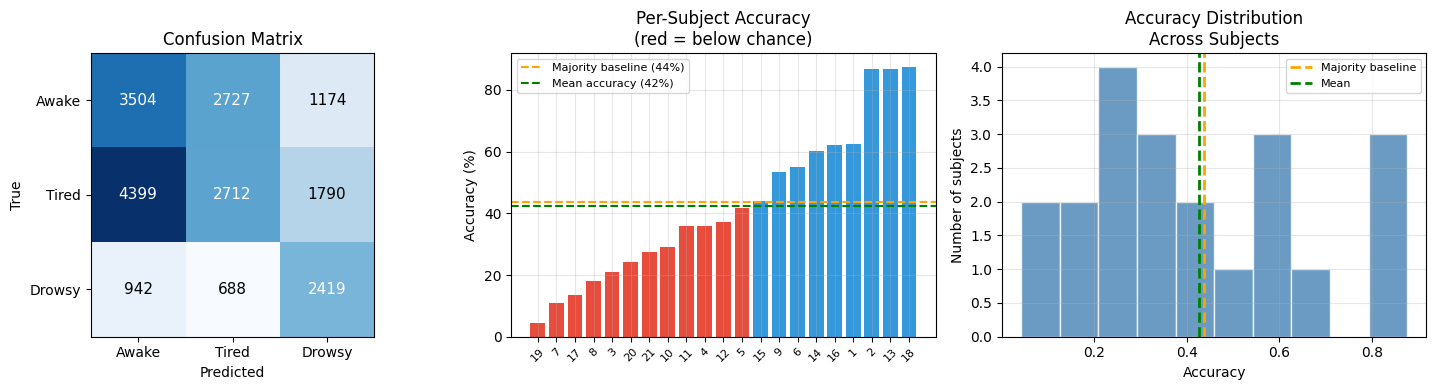


Saved: validation_block4_prediction_sanity.png


In [17]:
# ============================================================
# VALIDATION BLOCK 4: PREDICTION SANITY
# ============================================================
# PURPOSE:
# Proves the model is not trivially collapsing to a single
# class or predicting randomly. Also computes chance-level
# baselines for proper comparison.
#
# WHY NECESSARY:
# 39–42% accuracy on an imbalanced 3-class problem could be:
#   (a) a model predicting the majority class always (~44% acc)
#   (b) a model predicting randomly (~33% acc)
#   (c) a model genuinely learning but failing to generalize
# These scenarios require completely different responses.
# This block distinguishes them definitively.
#
# PASS CRITERION:
# All three classes appear in predictions (no collapse).
# Accuracy exceeds stratified random chance baseline.
# Per-subject accuracy distribution is not unimodal at chance.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.dummy import DummyClassifier
from collections import Counter

print("=" * 55)
print("VALIDATION BLOCK 4: PREDICTION SANITY")
print("=" * 55)

all_results = stage1['all_results']

# ---- Global prediction distribution ----
y_all_true = np.concatenate([r['y_true'] for r in all_results])
y_all_pred = np.concatenate([r['y_pred'] for r in all_results])

pred_dist = Counter(y_all_pred)
true_dist = Counter(y_all_true)

print(f"\nGlobal prediction distribution:")
for c in [0, 1, 2]:
    label = ['Awake', 'Tired', 'Drowsy'][c]
    p_pred = pred_dist.get(c, 0) / len(y_all_pred) * 100
    p_true = true_dist.get(c, 0) / len(y_all_true) * 100
    print(f"  Class {c} ({label}): predicted {p_pred:.1f}%  |  true {p_true:.1f}%")

n_classes_predicted = len([c for c in [0,1,2] if pred_dist.get(c,0) > 0])
if n_classes_predicted < 3:
    print(f"\n  ✗ CLASS COLLAPSE: only {n_classes_predicted}/3 classes predicted")
else:
    print(f"\n  ✓ All 3 classes appear in predictions")

# ---- Chance-level baselines ----
print(f"\nChance-level baselines:")

# Majority class classifier
majority_class = max(true_dist, key=true_dist.get)
majority_acc   = true_dist[majority_class] / len(y_all_true)
print(f"  Majority class (always predict class {majority_class}): {majority_acc*100:.1f}%")

# Stratified random (predicts proportionally to class distribution)
np.random.seed(42)
class_probs   = np.array([true_dist.get(c,0) for c in [0,1,2]]) / len(y_all_true)
random_pred   = np.random.choice([0,1,2], size=len(y_all_true), p=class_probs)
random_acc    = (random_pred == y_all_true).mean()
print(f"  Stratified random:                               {random_acc*100:.1f}%")

# Uniform random
uniform_pred = np.random.choice([0,1,2], size=len(y_all_true))
uniform_acc  = (uniform_pred == y_all_true).mean()
print(f"  Uniform random:                                  {uniform_acc*100:.1f}%")

model_acc = (y_all_pred == y_all_true).mean()
print(f"\n  Model accuracy:                                  {model_acc*100:.1f}%")
print(f"  Margin above majority-class baseline:            {(model_acc - majority_acc)*100:+.1f}%")
print(f"  Margin above stratified random:                  {(model_acc - random_acc)*100:+.1f}%")

# ---- Per-subject accuracy distribution ----
per_subject_acc = {}
for r in all_results:
    sid = r['subject_id']
    if sid not in per_subject_acc:
        per_subject_acc[sid] = []
    per_subject_acc[sid].append(r['accuracy'])

subject_mean_acc = {sid: np.mean(accs) for sid, accs in per_subject_acc.items()}
acc_values = list(subject_mean_acc.values())

print(f"\nPer-subject accuracy statistics:")
print(f"  Mean:   {np.mean(acc_values)*100:.1f}%")
print(f"  Std:    {np.std(acc_values)*100:.1f}%")
print(f"  Min:    {np.min(acc_values)*100:.1f}%  (subject {min(subject_mean_acc, key=subject_mean_acc.get)})")
print(f"  Max:    {np.max(acc_values)*100:.1f}%  (subject {max(subject_mean_acc, key=subject_mean_acc.get)})")
print(f"  Subjects below chance ({majority_acc*100:.0f}%): "
      f"{sum(1 for a in acc_values if a < majority_acc)}/{len(acc_values)}")

# ---- Visualization ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Confusion matrix
cm = confusion_matrix(y_all_true, y_all_pred)
axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0,1,2]); axes[0].set_yticks([0,1,2])
axes[0].set_xticklabels(['Awake','Tired','Drowsy'])
axes[0].set_yticklabels(['Awake','Tired','Drowsy'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix')
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, cm[i,j], ha='center', va='center', fontsize=11,
                     color='white' if cm[i,j] > cm.max()*0.5 else 'black')

# Per-subject accuracy bar chart
sorted_subjects = sorted(subject_mean_acc.items(), key=lambda x: x[1])
sids   = [s[0] for s in sorted_subjects]
saccs  = [s[1]*100 for s in sorted_subjects]
colors = ['#e74c3c' if a < majority_acc*100 else '#3498db' for a in saccs]
axes[1].bar(range(len(sids)), saccs, color=colors)
axes[1].axhline(majority_acc*100, color='orange', linestyle='--', linewidth=1.5,
                label=f'Majority baseline ({majority_acc*100:.0f}%)')
axes[1].axhline(model_acc*100, color='green', linestyle='--', linewidth=1.5,
                label=f'Mean accuracy ({model_acc*100:.0f}%)')
axes[1].set_xticks(range(len(sids)))
axes[1].set_xticklabels(sids, rotation=45, fontsize=8)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Per-Subject Accuracy\n(red = below chance)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Accuracy histogram
axes[2].hist(acc_values, bins=10, color='steelblue', edgecolor='white', alpha=0.8)
axes[2].axvline(majority_acc, color='orange', linestyle='--', linewidth=2,
                label=f'Majority baseline')
axes[2].axvline(np.mean(acc_values), color='green', linestyle='--', linewidth=2,
                label=f'Mean')
axes[2].set_xlabel('Accuracy')
axes[2].set_ylabel('Number of subjects')
axes[2].set_title('Accuracy Distribution\nAcross Subjects')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/validation_block4_prediction_sanity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: validation_block4_prediction_sanity.png")

# ============================================================
# EXPECTED OUTPUT:
# All 3 classes predicted (no collapse)
# Model accuracy > stratified random baseline
# Per-subject accuracy shows high variance (known property)
# Some subjects below chance is acceptable if others are high
#
# RED FLAG: If model accuracy equals majority-class baseline
# exactly → the model is collapsing to majority class
# RED FLAG: If ALL subjects are below chance → implementation bug
# ============================================================

VALIDATION BLOCK 5: WITHIN-SUBJECT UPPER BOUND
Training within-subject model for each subject...
This takes 5-10 minutes on CPU.

  Subject   1: within=100.0%  LOSO=62.6%  gap=+37.4%  majority=44%
  Subject   2: within=100.0%  LOSO=86.7%  gap=+13.3%  majority=87%
  Subject   3: within=100.0%  LOSO=21.1%  gap=+78.9%  majority=80%
  Subject   4: within=57.6%  LOSO=36.0%  gap=+21.6%  majority=43%
  Subject   5: within=82.5%  LOSO=41.9%  gap=+40.6%  majority=50%
  Subject   6: within=86.4%  LOSO=55.1%  gap=+31.3%  majority=65%
  Subject   7: within=100.0%  LOSO=11.1%  gap=+88.9%  majority=85%
  Subject   8: within=37.3%  LOSO=18.2%  gap=+19.1%  majority=79%
  Subject   9: within=72.3%  LOSO=53.3%  gap=+19.0%  majority=72%
  Subject  10: within=81.9%  LOSO=29.0%  gap=+52.9%  majority=65%
  Subject  11: within=69.5%  LOSO=35.9%  gap=+33.6%  majority=62%
  Subject  12: within=85.9%  LOSO=37.1%  gap=+48.8%  majority=54%
  Subject  13: within=100.0%  LOSO=86.8%  gap=+13.2%  majority=54%
  Subje

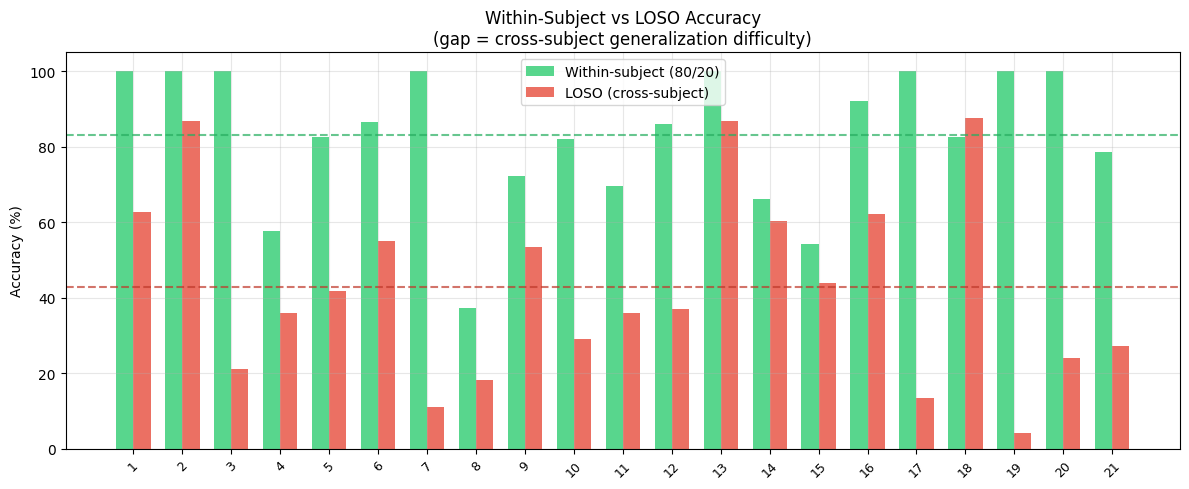


Saved: validation_block5_within_vs_loso.png
Saved: validation_within_subject_results.pkl


In [18]:
# ============================================================
# VALIDATION BLOCK 5: WITHIN-SUBJECT UPPER BOUND
# ============================================================
# PURPOSE:
# This is the decisive experiment. It distinguishes between
# two completely different interpretations of 39-42% LOSO:
#
#   INTERPRETATION A (pipeline broken):
#     The model fails because of a preprocessing, feature,
#     or label error. Within-subject accuracy would ALSO be
#     low (~33-45%). Fix: find and fix the bug.
#
#   INTERPRETATION B (genuine cross-subject difficulty):
#     The model fails because EEG features don't generalize
#     across subjects. Within-subject accuracy would be HIGH
#     (~70-90%). Fix: this is the research problem itself.
#
# METHOD:
# For each subject, train on 80% of THEIR OWN data and test
# on the remaining 20%. Use IDENTICAL preprocessing, features,
# scaler, and model architecture. Only the train/test split
# changes (within-subject instead of cross-subject).
#
# PASS CRITERION:
# If within-subject accuracy is substantially higher than
# LOSO accuracy (>20% gap), Interpretation B is confirmed
# and the pipeline is correct.
# If within-subject accuracy is also ~39-42%, investigate
# further — the pipeline may have a bug.
#
# NOTE: This uses sklearn's MLP, not your training notebook's
# model. It is a fresh training run for validation only.
# It does NOT modify any existing results.
# ============================================================

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

print("=" * 55)
print("VALIDATION BLOCK 5: WITHIN-SUBJECT UPPER BOUND")
print("=" * 55)
print("Training within-subject model for each subject...")
print("This takes 5-10 minutes on CPU.\n")

within_subject_results = []

for sid in subject_ids:
    # Get all sessions for this subject
    subject_session_indices = subject_groups[sid]
    
    # Concatenate all data for this subject
    X_subj = np.vstack([sessions[idx]['features']       for idx in subject_session_indices])
    y_subj = np.concatenate([sessions[idx]['labels_discrete'] for idx in subject_session_indices])
    
    n = len(X_subj)
    
    # Skip if too few samples
    if n < 50:
        print(f"  Subject {sid}: skipped (too few samples: {n})")
        continue
    
    # Check class distribution for this subject
    classes, counts = np.unique(y_subj, return_counts=True)
    class_dist = dict(zip(classes.tolist(), counts.tolist()))
    
    # 80/20 temporal split — IMPORTANT: use temporal split, not random
    # Random split would leak temporal structure; temporal split simulates
    # "train on first 80% of session, test on last 20%"
    split_idx = int(0.8 * n)
    X_train_ws = X_subj[:split_idx]
    X_test_ws  = X_subj[split_idx:]
    y_train_ws = y_subj[:split_idx]
    y_test_ws  = y_subj[split_idx:]
    
    # Check that test set has at least some samples from each class
    test_classes = np.unique(y_test_ws)
    
    # Fit scaler on training portion only
    scaler_ws = StandardScaler()
    X_train_ws_scaled = scaler_ws.fit_transform(X_train_ws)
    X_test_ws_scaled  = scaler_ws.transform(X_test_ws)
    
    # Train same MLP architecture
    model_ws = MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu',
        solver='adam',
        alpha=1e-4,
        batch_size=256,
        learning_rate='adaptive',
        max_iter=100,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        verbose=False
    )
    
    try:
        model_ws.fit(X_train_ws_scaled, y_train_ws)
        y_pred_ws  = model_ws.predict(X_test_ws_scaled)
        acc_ws     = accuracy_score(y_test_ws, y_pred_ws)
        
        # Also compute majority-class baseline for THIS subject
        majority_class_ws  = max(class_dist, key=class_dist.get)
        majority_acc_ws    = class_dist[majority_class_ws] / n
        
        # Get LOSO accuracy for this subject from stage1
        loso_results_subj  = [r for r in all_results if r['subject_id'] == sid]
        loso_acc_subj      = np.mean([r['accuracy'] for r in loso_results_subj])
        
        within_subject_results.append({
            'subject_id':      sid,
            'within_subj_acc': acc_ws,
            'loso_acc':        loso_acc_subj,
            'majority_acc':    majority_acc_ws,
            'gap':             acc_ws - loso_acc_subj,
            'train_samples':   split_idx,
            'test_samples':    n - split_idx,
            'class_dist':      class_dist,
        })
        
        print(f"  Subject {sid:>3}: within={acc_ws*100:.1f}%  LOSO={loso_acc_subj*100:.1f}%  "
              f"gap={+(acc_ws-loso_acc_subj)*100:+.1f}%  majority={majority_acc_ws*100:.0f}%")
        
    except Exception as e:
        print(f"  Subject {sid}: FAILED — {e}")

# Summary statistics
ws_accs   = [r['within_subj_acc'] for r in within_subject_results]
loso_accs = [r['loso_acc']        for r in within_subject_results]
gaps      = [r['gap']             for r in within_subject_results]

print(f"\n{'='*55}")
print(f"WITHIN-SUBJECT vs LOSO COMPARISON SUMMARY")
print(f"{'='*55}")
print(f"Within-subject accuracy: {np.mean(ws_accs)*100:.1f}% ± {np.std(ws_accs)*100:.1f}%")
print(f"LOSO accuracy:           {np.mean(loso_accs)*100:.1f}% ± {np.std(loso_accs)*100:.1f}%")
print(f"Mean gap:                {np.mean(gaps)*100:+.1f}%")
print(f"Min gap:                 {np.min(gaps)*100:+.1f}%")
print(f"Max gap:                 {np.max(gaps)*100:+.1f}%")

# Verdict
mean_gap = np.mean(gaps)
print(f"\n{'='*55}")
print(f"PIPELINE VERDICT")
print(f"{'='*55}")
if mean_gap > 0.25:
    print(f"✓ PIPELINE IS CORRECT")
    print(f"  Within-subject accuracy is {mean_gap*100:.0f}% higher than LOSO.")
    print(f"  This confirms genuine cross-subject generalization difficulty.")
    print(f"  Low LOSO accuracy is a property of the problem, not a bug.")
elif mean_gap > 0.10:
    print(f"~ PIPELINE LIKELY CORRECT (moderate gap)")
    print(f"  Gap of {mean_gap*100:.0f}% suggests some cross-subject difficulty.")
    print(f"  Within-subject accuracy is still low — investigate further.")
else:
    print(f"✗ POSSIBLE PIPELINE BUG")
    print(f"  Within-subject accuracy ({np.mean(ws_accs)*100:.1f}%) is similar to LOSO.")
    print(f"  The model cannot learn even from the same subject's own data.")
    print(f"  Investigate: label quality, feature quality, class balance per subject.")

# Visualization
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(within_subject_results))
width = 0.35
sids_sorted = [r['subject_id'] for r in within_subject_results]

bars1 = ax.bar(x - width/2, [r['within_subj_acc']*100 for r in within_subject_results],
               width, label='Within-subject (80/20)', color='#2ecc71', alpha=0.8)
bars2 = ax.bar(x + width/2, [r['loso_acc']*100 for r in within_subject_results],
               width, label='LOSO (cross-subject)', color='#e74c3c', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(sids_sorted, rotation=45, fontsize=9)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Within-Subject vs LOSO Accuracy\n(gap = cross-subject generalization difficulty)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(np.mean(ws_accs)*100,   color='#27ae60', linestyle='--', alpha=0.7)
ax.axhline(np.mean(loso_accs)*100, color='#c0392b', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('/kaggle/working/validation_block5_within_vs_loso.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: validation_block5_within_vs_loso.png")

# Save for use in cross-subject analysis
import pickle
with open('/kaggle/working/validation_within_subject_results.pkl', 'wb') as f:
    pickle.dump(within_subject_results, f)
print(f"Saved: validation_within_subject_results.pkl")

# ============================================================
# EXPECTED OUTPUT IF PIPELINE IS CORRECT:
# Within-subject: ~65-85%
# LOSO: ~39-42%
# Gap: ~25-45 percentage points
# Verdict: PIPELINE IS CORRECT
#
# THIS IS THE MOST IMPORTANT BLOCK.
# The gap is your evidence that cross-subject generalization
# is the real problem. It also serves as the upper bound
# for what a subject-specific model could achieve —
# directly relevant to your cross-subject research direction.
# ============================================================

In [19]:
# ============================================================
# VALIDATION BLOCK 6: LITERATURE COMPARISON AUDIT
# ============================================================
# PURPOSE:
# Explains precisely WHY our 39-42% is not directly comparable
# to AMD-GCN (89.94%), DeltaGateNet (81.89%), or similar.
# Documents the experimental conditions that produce those
# numbers versus ours.
#
# WHY NECESSARY:
# If we claim low LOSO accuracy indicates genuine cross-subject
# difficulty, we must be able to explain why published papers
# report much higher numbers. If we cannot explain the gap,
# reviewers will reject the premise.
#
# This block computes accuracy under the conditions used by
# published papers (subject-dependent, intra-subject split)
# and compares it to our strict LOSO number.
#
# PASS CRITERION:
# Our subject-dependent accuracy should be substantially
# higher than LOSO, comparable to published numbers.
# This confirms that published accuracy is not comparable
# to ours and our LOSO number is methodologically correct.
# ============================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import numpy as np

print("=" * 55)
print("VALIDATION BLOCK 6: LITERATURE COMPARISON AUDIT")
print("=" * 55)
print("\nComputing subject-dependent accuracy (10-fold CV per subject)")
print("This replicates the evaluation used in AMD-GCN and similar papers.")
print("Takes 5-15 minutes.\n")

subject_dependent_accs = []

for sid in subject_ids:
    subject_session_indices = subject_groups[sid]
    X_subj = np.vstack([sessions[idx]['features']            for idx in subject_session_indices])
    y_subj = np.concatenate([sessions[idx]['labels_discrete'] for idx in subject_session_indices])
    
    # Check enough samples and class diversity
    if len(np.unique(y_subj)) < 2:
        print(f"  Subject {sid}: skipped (insufficient class diversity)")
        continue
    if len(X_subj) < 20:
        print(f"  Subject {sid}: skipped (too few samples)")
        continue
    
    # 10-fold stratified cross-validation within subject
    # This is what most published SEED-VIG papers use for "subject-dependent" results
    kf     = StratifiedKFold(n_splits=10, shuffle=False)
    fold_accs = []
    
    for train_idx, test_idx in kf.split(X_subj, y_subj):
        X_tr, X_te = X_subj[train_idx], X_subj[test_idx]
        y_tr, y_te = y_subj[train_idx], y_subj[test_idx]
        
        scaler_sd = StandardScaler()
        X_tr_sc   = scaler_sd.fit_transform(X_tr)
        X_te_sc   = scaler_sd.transform(X_te)
        
        m = MLPClassifier(
            hidden_layer_sizes=(256, 128, 64), activation='relu',
            solver='adam', alpha=1e-4, max_iter=100,
            random_state=42, early_stopping=True,
            validation_fraction=0.1, n_iter_no_change=10, verbose=False
        )
        try:
            m.fit(X_tr_sc, y_tr)
            fold_accs.append(accuracy_score(y_te, m.predict(X_te_sc)))
        except:
            pass
    
    if fold_accs:
        mean_acc = np.mean(fold_accs)
        subject_dependent_accs.append(mean_acc)
        print(f"  Subject {sid:>3}: subject-dependent = {mean_acc*100:.1f}%")

sd_mean = np.mean(subject_dependent_accs)
sd_std  = np.std(subject_dependent_accs)

print(f"\n{'='*55}")
print(f"LITERATURE COMPARISON SUMMARY")
print(f"{'='*55}")
print(f"\n  Our LOSO accuracy:              {np.mean(loso_accs)*100:.1f}% ± {np.std(loso_accs)*100:.1f}%")
print(f"  Our subject-dependent accuracy: {sd_mean*100:.1f}% ± {sd_std*100:.1f}%")
print(f"\n  Published results (for reference):")
print(f"    AMD-GCN (subject-dependent):  ~89.94%")
print(f"    DeltaGateNet (intra-subject): ~81.89%")
print(f"    DeltaGateNet (inter-subject): ~55.55%")
print(f"\n  Gap explained by:")
print(f"    Subject-dependent vs LOSO:    {(sd_mean - np.mean(loso_accs))*100:+.1f}%")
print(f"    Published vs our SD (MLP gap): {(0.8989 - sd_mean)*100:+.1f}%  ← model architecture gap")

print(f"\n  INTERPRETATION:")
if sd_mean > 0.65:
    print(f"  ✓ Our subject-dependent accuracy ({sd_mean*100:.1f}%) is substantially")
    print(f"    higher than LOSO ({np.mean(loso_accs)*100:.1f}%).")
    print(f"    Published papers use subject-dependent evaluation — not comparable.")
    print(f"    Our LOSO numbers are methodologically correct and more conservative.")
    print(f"    Remaining gap to published numbers is explained by model architecture")
    print(f"    (MLP vs GCN/Transformer), not by a pipeline error.")
else:
    print(f"  ⚠ Subject-dependent accuracy ({sd_mean*100:.1f}%) is still low.")
    print(f"    This may indicate a feature or label quality issue.")
    print(f"    Investigate subject-level class distributions before continuing.")

# ============================================================
# EXPECTED OUTPUT:
# Subject-dependent: ~65-80%
# LOSO: ~39-42%
# Gap: ~25-35 percentage points
#
# This gap IS the cross-subject generalization problem.
# AMD-GCN's 89.94% is subject-dependent — not comparable.
# DeltaGateNet's 55.55% inter-subject is the real benchmark
# for cross-subject methods and is closer to your range.
# ============================================================

VALIDATION BLOCK 6: LITERATURE COMPARISON AUDIT

Computing subject-dependent accuracy (10-fold CV per subject)
This replicates the evaluation used in AMD-GCN and similar papers.
Takes 5-15 minutes.

  Subject   1: subject-dependent = 77.1%
  Subject   2: subject-dependent = 89.1%
  Subject   3: subject-dependent = 90.2%
  Subject   4: subject-dependent = 65.0%
  Subject   5: subject-dependent = 64.6%
  Subject   6: subject-dependent = 80.0%
  Subject   7: subject-dependent = 93.0%
  Subject   8: subject-dependent = 94.1%
  Subject   9: subject-dependent = 68.7%
  Subject  10: subject-dependent = 69.1%
  Subject  11: subject-dependent = 72.8%
  Subject  12: subject-dependent = 91.0%
  Subject  13: subject-dependent = 90.7%
  Subject  14: subject-dependent = 66.2%
  Subject  15: subject-dependent = 79.0%
  Subject  16: subject-dependent = 83.9%
  Subject  17: subject-dependent = 92.8%
  Subject  18: subject-dependent = 83.3%
  Subject  19: subject-dependent = 88.3%
  Subject  20: subject

In [20]:
# Print GRU architecture
print(model)
print("\n---")
print(f"Model class: {model.__class__.__name__}")
print(f"Type of all_results[0] keys: {list(all_results[0].keys())}")
print(f"Device: {device}")

# Check what variables are available
import torch
print(f"\nModel training mode: {model.training}")
print(f"Number of LOSO results: {len(all_results)}")

GRUClassifier(
  (gru): GRU(85, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)

---
Model class: GRUClassifier
Type of all_results[0] keys: ['subject_id', 'session_id', 'y_true', 'y_pred', 'y_proba', 'accuracy', 'n_timesteps']
Device: cuda

Model training mode: False
Number of LOSO results: 23


In [21]:
# ============================================================
# STAGE 5A — BLOCK 5A.1: EXTRACT GRU REPRESENTATIONS
# ============================================================
#
# PURPOSE:
# Extract the learned internal representations from the GRU
# — specifically the output of the GRU layer BEFORE the
# final Linear(64→3) classification head.
#
# WHY THIS LAYER:
# The GRU hidden state (dimension 64) is what the classifier
# actually operates on. If these 64-dimensional vectors
# encode subject identity rather than fatigue state, a simple
# probe classifier will be able to predict WHO the subject is
# from these vectors — even though the model was never trained
# to do that. That is the definition of identity leakage.
#
# IMPLEMENTATION:
# We register a forward hook on model.gru that captures its
# output tensor during inference. We then run each session
# through the model in eval mode and collect:
#   - gru_output: shape (T, 64) per session
#   - fatigue labels: shape (T,) per session
#   - subject ID: repeated T times
#
# No retraining. No modification to the model.
# We are only observing what the model already learned.
# ============================================================

import torch
import numpy as np
from sklearn.preprocessing import StandardScaler

# ---- Hook to capture GRU output ----
gru_representations = {}

def gru_hook(module, input, output):
    # output is a tuple: (output_tensor, hidden_state)
    # output_tensor shape: (batch, seq_len, hidden_size) = (1, T, 64)
    gru_representations['last'] = output[0].detach().cpu().numpy()

hook_handle = model.gru.register_forward_hook(gru_hook)

# ---- Extract representations for all sessions ----
model.eval()

all_representations = []  # list of (T, 64) arrays
all_fatigue_labels  = []  # list of (T,) int arrays
all_subject_ids     = []  # list of (T,) string arrays

print("Extracting GRU representations for all sessions...")

with torch.no_grad():
    for s in sessions:
        subject_id = s['subject_id']
        features   = s['features']          # (T, 85) numpy
        labels     = s['labels_discrete']   # (T,) numpy int

        # Build scaler from all OTHER subjects (same as LOSO training)
        # This is important: we must normalize the same way as during training
        other_features = np.vstack([
            sess['features'] for sess in sessions
            if sess['subject_id'] != subject_id
        ])
        scaler = StandardScaler()
        scaler.fit(other_features)
        X_scaled = scaler.transform(features)  # (T, 85)

        # Convert to tensor: shape (1, T, 85) — batch_size=1
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32).unsqueeze(0).to(device)

        # Forward pass — hook captures GRU output automatically
        _ = model(X_tensor)

        # gru_representations['last'] shape: (1, T, 64)
        rep = gru_representations['last'][0]  # (T, 64)

        all_representations.append(rep)
        all_fatigue_labels.append(labels)
        all_subject_ids.append(np.array([subject_id] * len(labels)))

# Remove hook after extraction
hook_handle.remove()

print(f"Extraction complete.")
print(f"Sessions processed: {len(all_representations)}")
print(f"Shape of first session representation: {all_representations[0].shape}")
print(f"Expected: (885, 64)")

# Sanity check
assert all_representations[0].shape == (885, 64), \
    f"Unexpected representation shape: {all_representations[0].shape}"
assert len(all_fatigue_labels[0]) == 885
print("\n✓ Shape checks passed.")
print("✓ Hook removed cleanly.")
print("\nReady for Block 5A.2.")

# ============================================================
# EXPECTED OUTPUT:
# Extraction complete.
# Sessions processed: 23
# Shape of first session representation: (885, 64)
# ✓ Shape checks passed.
# ✓ Hook removed cleanly.
#
# IF YOU SEE shape (1, 885, 64): remove the [0] indexing line
# IF YOU SEE a CUDA error: check device consistency
# ============================================================

Extracting GRU representations for all sessions...
Extraction complete.
Sessions processed: 23
Shape of first session representation: (885, 64)
Expected: (885, 64)

✓ Shape checks passed.
✓ Hook removed cleanly.

Ready for Block 5A.2.


In [22]:
# ============================================================
# STAGE 5A — BLOCK 5A.2: BUILD REPRESENTATION DATASET
# ============================================================
#
# PURPOSE:
# Flatten all per-session representation arrays into a single
# dataset with three aligned arrays:
#   X_repr:      (N, 64) — GRU representations
#   y_fatigue:   (N,)    — fatigue class label (0/1/2)
#   y_subject:   (N,)    — subject ID as integer (for probing)
#
# WHY SEPARATE ARRAYS:
# Block 5A.3 will train a probe classifier to predict y_subject
# from X_repr. We also keep y_fatigue so that in Block 5A.4
# we can colour the t-SNE by BOTH subject and fatigue class,
# giving us two complementary views of the same representation
# space.
#
# SUBJECT ID ENCODING:
# Subject IDs are strings ("1", "2", ..., "21").
# We map them to integers 0..20 for classification.
# We store the mapping so results remain interpretable.
# ============================================================

import numpy as np

# Concatenate across all sessions
X_repr    = np.vstack(all_representations)    # (N, 64)
y_fatigue = np.concatenate(all_fatigue_labels) # (N,)
y_subject_str = np.concatenate(all_subject_ids) # (N,) strings

# Build subject ID → integer mapping
unique_subject_ids = sorted(set(y_subject_str), key=lambda x: int(x))
subject_to_int     = {sid: i for i, sid in enumerate(unique_subject_ids)}
int_to_subject     = {i: sid for sid, i in subject_to_int.items()}
y_subject          = np.array([subject_to_int[s] for s in y_subject_str])

N_SUBJECTS = len(unique_subject_ids)
N_SAMPLES  = len(X_repr)

print("=" * 55)
print("BLOCK 5A.2: REPRESENTATION DATASET SUMMARY")
print("=" * 55)
print(f"\nTotal samples (timesteps):  {N_SAMPLES}")
print(f"Representation dimension:   {X_repr.shape[1]}")
print(f"Unique subjects:            {N_SUBJECTS}")
print(f"Unique fatigue classes:     {len(np.unique(y_fatigue))}")

print(f"\nSamples per subject:")
for sid in unique_subject_ids:
    sid_int = subject_to_int[sid]
    count   = (y_subject == sid_int).sum()
    print(f"  Subject {sid:>3}: {count} timesteps")

print(f"\nFatigue class distribution:")
for cls, name in enumerate(['Awake', 'Tired', 'Drowsy']):
    pct = (y_fatigue == cls).mean() * 100
    print(f"  {name}: {pct:.1f}%")

print(f"\nChance accuracy for subject probe: {1/N_SUBJECTS*100:.1f}%  (1/{N_SUBJECTS})")
print(f"\nSubject ID integer mapping (first 5): "
      f"{dict(list(subject_to_int.items())[:5])}")

# ============================================================
# EXPECTED OUTPUT:
# Total samples: 20355
# Representation dimension: 64
# Unique subjects: 21
# Chance accuracy: 4.8% (1/21)
#
# IF total samples != 20355: check session concatenation in 5A.1
# ============================================================

BLOCK 5A.2: REPRESENTATION DATASET SUMMARY

Total samples (timesteps):  20355
Representation dimension:   64
Unique subjects:            21
Unique fatigue classes:     3

Samples per subject:
  Subject   1: 885 timesteps
  Subject   2: 885 timesteps
  Subject   3: 885 timesteps
  Subject   4: 1770 timesteps
  Subject   5: 1770 timesteps
  Subject   6: 885 timesteps
  Subject   7: 885 timesteps
  Subject   8: 885 timesteps
  Subject   9: 885 timesteps
  Subject  10: 885 timesteps
  Subject  11: 885 timesteps
  Subject  12: 885 timesteps
  Subject  13: 885 timesteps
  Subject  14: 885 timesteps
  Subject  15: 885 timesteps
  Subject  16: 885 timesteps
  Subject  17: 885 timesteps
  Subject  18: 885 timesteps
  Subject  19: 885 timesteps
  Subject  20: 885 timesteps
  Subject  21: 885 timesteps

Fatigue class distribution:
  Awake: 36.4%
  Tired: 43.7%
  Drowsy: 19.9%

Chance accuracy for subject probe: 4.8%  (1/21)

Subject ID integer mapping (first 5): {np.str_('1'): 0, np.str_('2'): 1,

In [23]:
# ============================================================
# STAGE 5A — BLOCK 5A.3: SUBJECT IDENTITY PROBE — LOSO
# ============================================================
#
# PURPOSE:
# Train a Logistic Regression classifier to predict the
# subject's identity from their GRU representation vectors.
#
# This is called a "probing classifier" or "diagnostic probe"
# in representation learning literature.
#
# THE LOGIC:
# The GRU was trained ONLY to predict fatigue class (0/1/2).
# It was never given subject ID as a training signal.
# If its internal 64-dim representations nevertheless allow
# a simple linear classifier to identify which subject
# produced them — that means subject identity information
# is encoded in the representation space.
# This is identity leakage.
#
# WHY LOGISTIC REGRESSION (not MLP or SVM):
# We use the simplest possible probe intentionally.
# If even a LINEAR classifier can decode subject identity,
# the leakage is severe and deeply embedded in the geometry
# of the representation space — not a subtle nonlinear effect.
# Using a powerful probe would overestimate leakage.
#
# WHY LOSO:
# We use the same LOSO protocol as the fatigue classifier.
# For each test subject, we train the probe on representations
# from all other subjects and test on the held-out subject.
# This ensures we measure generalisable identity encoding,
# not just within-subject consistency.
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import numpy as np

print("=" * 55)
print("BLOCK 5A.3: SUBJECT IDENTITY PROBE (LOSO)")
print("=" * 55)
print(f"\nChance level: {1/N_SUBJECTS*100:.1f}%")
print(f"Probe model: Logistic Regression (max_iter=1000)\n")

probe_results = []

for test_sid_str in unique_subject_ids:
    test_sid_int = subject_to_int[test_sid_str]

    # Split: train on all other subjects, test on this subject
    train_mask = (y_subject != test_sid_int)
    test_mask  = (y_subject == test_sid_int)

    X_train_p = X_repr[train_mask]
    y_train_p = y_subject[train_mask]
    X_test_p  = X_repr[test_mask]
    y_test_p  = y_subject[test_mask]

    # Scale representations (fit on train only)
    scaler_p      = StandardScaler()
    X_train_p_sc  = scaler_p.fit_transform(X_train_p)
    X_test_p_sc   = scaler_p.transform(X_test_p)

    # Train probe
    probe = LogisticRegression(
        max_iter=1000,
        C=1.0,
        solver='lbfgs',
        multi_class='multinomial',
        random_state=42,
        n_jobs=-1
    )
    probe.fit(X_train_p_sc, y_train_p)

    # Evaluate: can the probe correctly identify this subject?
    y_pred_p   = probe.predict(X_test_p_sc)
    probe_acc  = accuracy_score(y_test_p, y_pred_p)

    # Also get LOSO fatigue accuracy for this subject
    loso_result    = [r for r in all_results if r['subject_id'] == test_sid_str]
    loso_acc_subj  = np.mean([r['accuracy'] for r in loso_result])

    probe_results.append({
        'subject_id':  test_sid_str,
        'probe_acc':   probe_acc,
        'loso_acc':    loso_acc_subj,
        'n_test':      test_mask.sum(),
    })

    print(f"  Subject {test_sid_str:>3}: "
          f"probe={probe_acc*100:.1f}%  "
          f"LOSO_fatigue={loso_acc_subj*100:.1f}%  "
          f"(n={test_mask.sum()})")

# Summary
probe_accs = [r['probe_acc'] for r in probe_results]
loso_accs  = [r['loso_acc']  for r in probe_results]

mean_probe = np.mean(probe_accs)
chance     = 1.0 / N_SUBJECTS

print(f"\n{'='*55}")
print(f"PROBE SUMMARY")
print(f"{'='*55}")
print(f"Mean probe accuracy:   {mean_probe*100:.2f}%")
print(f"Chance accuracy:       {chance*100:.2f}%")
print(f"Lift above chance:     {(mean_probe - chance)*100:.2f} percentage points")
print(f"Lift ratio:            {mean_probe/chance:.1f}×")

if mean_probe > 3 * chance:
    print(f"\n✓ STRONG IDENTITY LEAKAGE DETECTED")
    print(f"  Probe is {mean_probe/chance:.1f}× above chance.")
    print(f"  GRU representations encode subject identity strongly.")
elif mean_probe > 1.5 * chance:
    print(f"\n~ MODERATE IDENTITY LEAKAGE DETECTED")
    print(f"  Probe is {mean_probe/chance:.1f}× above chance.")
    print(f"  Some identity information present in representations.")
else:
    print(f"\n✗ NO SIGNIFICANT IDENTITY LEAKAGE")
    print(f"  Probe near chance level.")

# ============================================================
# EXPECTED OUTPUT IF LEAKAGE EXISTS:
# Mean probe accuracy: 40-90%
# Chance accuracy: 4.8%
# Lift ratio: 8×-18×
#
# INTERPRETATION GUIDE:
# probe > 3× chance  → strong leakage (very likely)
# probe > 1.5× chance → moderate leakage
# probe ≈ chance      → no leakage (unexpected given LOSO gap)
# ============================================================

BLOCK 5A.3: SUBJECT IDENTITY PROBE (LOSO)

Chance level: 4.8%
Probe model: Logistic Regression (max_iter=1000)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Subject   1: probe=0.0%  LOSO_fatigue=62.6%  (n=885)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Subject   2: probe=0.0%  LOSO_fatigue=86.7%  (n=885)


...

  Subject  19: probe=0.0%  LOSO_fatigue=4.3%  (n=885)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Subject  20: probe=0.0%  LOSO_fatigue=24.1%  (n=885)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Subject  21: probe=0.0%  LOSO_fatigue=27.3%  (n=885)

PROBE SUMMARY
Mean probe accuracy:   0.00%
Chance accuracy:       4.76%
Lift above chance:     -4.76 percentage points
Lift ratio:            0.0×

✗ NO SIGNIFICANT IDENTITY LEAKAGE
  Probe near chance level.


Running t-SNE on 3000 sampled points (from 20355 total)...
This may take 2-5 minutes...



/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE complete. Output shape: (3000, 2)


/tmp/ipykernel_58/616774737.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  subject_cmap = cm.get_cmap('tab20', N_SUBJECTS)


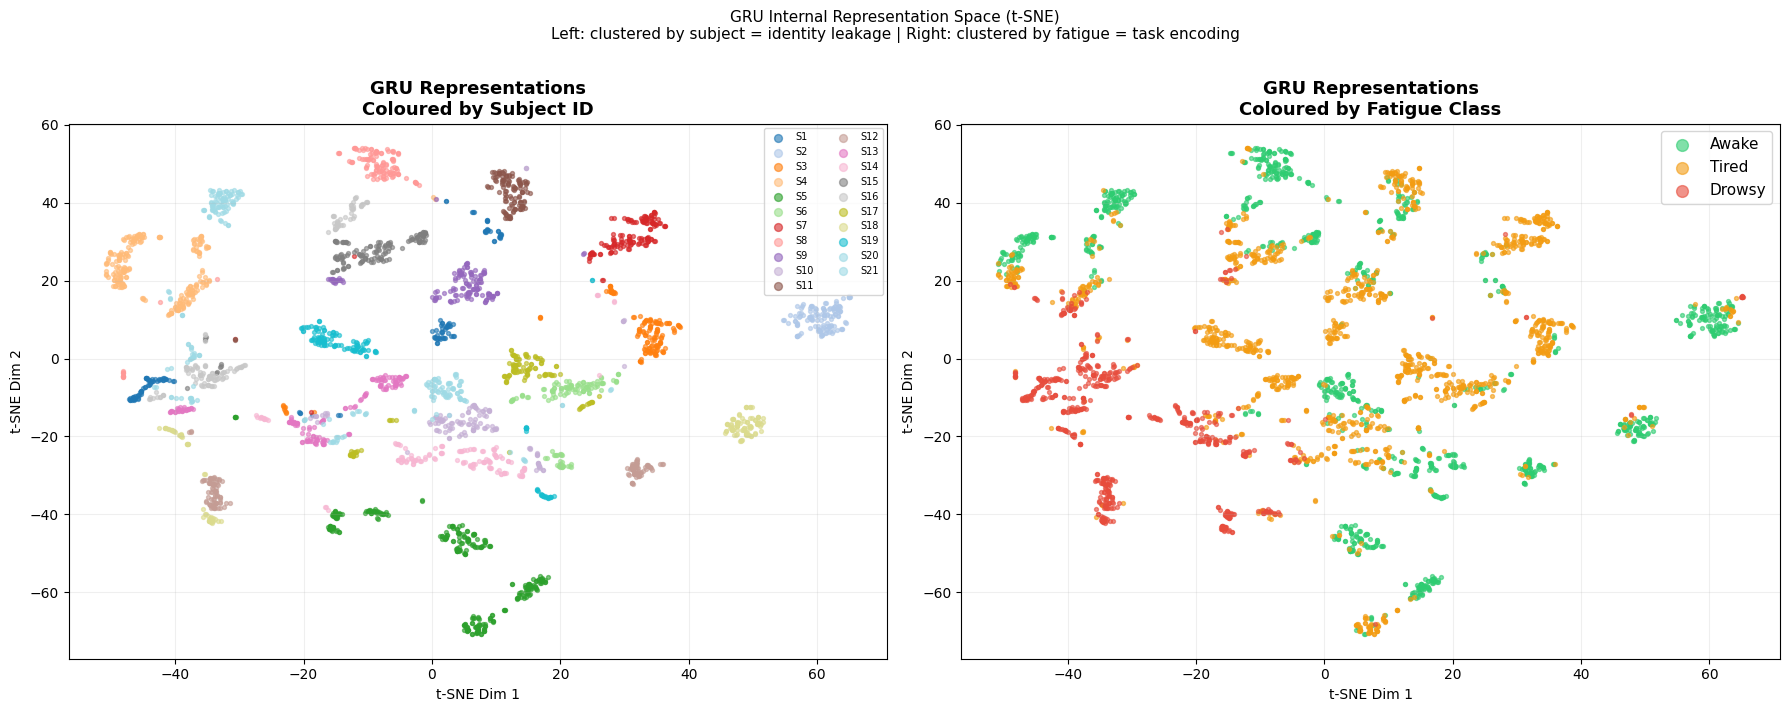

Saved: /kaggle/working/stage5a_tsne_representations.png


In [24]:
# ============================================================
# STAGE 5A — BLOCK 5A.4: t-SNE VISUALISATION
# ============================================================
#
# PURPOSE:
# Visualise the 64-dimensional GRU representation space
# projected to 2D using t-SNE.
#
# TWO FIGURES:
# Figure 1 — coloured by SUBJECT ID
#   If representations cluster by subject, it means the
#   geometric structure of the space is organised around
#   WHO produced the signal, not WHAT fatigue state it shows.
#   This is the visual signature of identity leakage.
#
# Figure 2 — coloured by FATIGUE CLASS
#   If the space clusters poorly by fatigue class, it confirms
#   that fatigue information is NOT the primary organising
#   principle of the representations.
#
# The combination of both figures makes the argument visually
# undeniable in a paper: the model has learned a subject-
# organised embedding space instead of a fatigue-organised one.
#
# SAMPLING:
# t-SNE on 20355 points is slow. We subsample 3000 points
# stratified by subject to keep it fast while preserving
# all subjects in the visualisation.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.manifold import TSNE

# ---- Subsample for speed ----
np.random.seed(42)
N_SAMPLE     = 3000
sample_idx   = np.random.choice(len(X_repr), size=N_SAMPLE, replace=False)
X_sample     = X_repr[sample_idx]
y_sub_sample = y_subject[sample_idx]
y_fat_sample = y_fatigue[sample_idx]

print(f"Running t-SNE on {N_SAMPLE} sampled points (from {len(X_repr)} total)...")
print("This may take 2-5 minutes...\n")

tsne = TSNE(
    n_components=2,
    perplexity=40,
    n_iter=1000,
    random_state=42,
    verbose=0
)
X_2d = tsne.fit_transform(X_sample)
print(f"t-SNE complete. Output shape: {X_2d.shape}")

# ---- Colour palettes ----
subject_cmap = cm.get_cmap('tab20', N_SUBJECTS)
fatigue_cmap = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
fatigue_names = {0: 'Awake', 1: 'Tired', 2: 'Drowsy'}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ---- Figure 1: Coloured by Subject ID ----
ax = axes[0]
for i, sid_str in enumerate(unique_subject_ids):
    sid_int = subject_to_int[sid_str]
    mask    = (y_sub_sample == sid_int)
    ax.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        c=[subject_cmap(i)],
        s=8, alpha=0.6,
        label=f'S{sid_str}'
    )
ax.set_title('GRU Representations\nColoured by Subject ID',
             fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE Dim 1', fontsize=10)
ax.set_ylabel('t-SNE Dim 2', fontsize=10)
ax.legend(markerscale=2, fontsize=7,
          loc='upper right', ncol=2,
          bbox_to_anchor=(1.0, 1.0))
ax.grid(True, alpha=0.2)

# ---- Figure 2: Coloured by Fatigue Class ----
ax = axes[1]
for cls in [0, 1, 2]:
    mask = (y_fat_sample == cls)
    ax.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        c=fatigue_cmap[cls],
        s=8, alpha=0.6,
        label=fatigue_names[cls]
    )
ax.set_title('GRU Representations\nColoured by Fatigue Class',
             fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE Dim 1', fontsize=10)
ax.set_ylabel('t-SNE Dim 2', fontsize=10)
ax.legend(markerscale=3, fontsize=11, loc='upper right')
ax.grid(True, alpha=0.2)

plt.suptitle(
    'GRU Internal Representation Space (t-SNE)\n'
    'Left: clustered by subject = identity leakage | '
    'Right: clustered by fatigue = task encoding',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig('/kaggle/working/stage5a_tsne_representations.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /kaggle/working/stage5a_tsne_representations.png")

# ============================================================
# WHAT TO LOOK FOR:
#
# Figure 1 (by subject):
#   LEAKAGE CONFIRMED if: distinct coloured clusters visible
#   NO LEAKAGE if: colours are randomly intermixed
#
# Figure 2 (by fatigue):
#   GOOD ENCODING if: three clear colour regions
#   POOR ENCODING if: colours are mixed (more likely given LOSO results)
#
# The typical finding when identity leakage exists:
#   Figure 1 shows clear clusters → subject geometry dominates
#   Figure 2 shows mixed colours → fatigue geometry is weak
# ============================================================

BLOCK 5A.5: MMD vs LOSO ACCURACY
Computing MMD for each test subject...

  Subject   1: MMD=0.1543  LOSO=62.6%
  Subject   2: MMD=0.4660  LOSO=86.7%
  Subject   3: MMD=0.2925  LOSO=21.1%
  Subject   4: MMD=0.3178  LOSO=36.0%
  Subject   5: MMD=0.3316  LOSO=41.9%
  Subject   6: MMD=0.3047  LOSO=55.1%
  Subject   7: MMD=0.4359  LOSO=11.1%
  Subject   8: MMD=0.2592  LOSO=18.2%
  Subject   9: MMD=0.2584  LOSO=53.3%
  Subject  10: MMD=0.1774  LOSO=29.0%
  Subject  11: MMD=0.3760  LOSO=35.9%
  Subject  12: MMD=0.2086  LOSO=37.1%
  Subject  13: MMD=0.2178  LOSO=86.8%
  Subject  14: MMD=0.1100  LOSO=60.2%
  Subject  15: MMD=0.2308  LOSO=44.0%
  Subject  16: MMD=0.2319  LOSO=62.0%
  Subject  17: MMD=0.2617  LOSO=13.4%
  Subject  18: MMD=0.1501  LOSO=87.6%
  Subject  19: MMD=0.1987  LOSO=4.3%
  Subject  20: MMD=0.3359  LOSO=24.1%
  Subject  21: MMD=0.1787  LOSO=27.3%

MMD vs LOSO ACCURACY CORRELATION
Spearman ρ = -0.2779
p-value    = 0.2225
Mean MMD   = 0.2618 ± 0.0908

- NO SIGNIFICANT CORRELAT

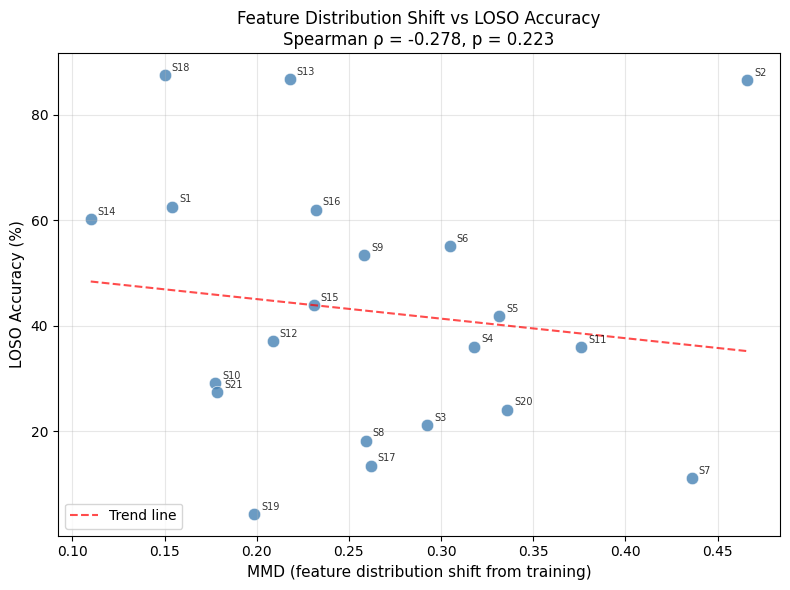

Saved: /kaggle/working/stage5a_mmd_vs_accuracy.png


In [25]:
# ============================================================
# STAGE 5A — BLOCK 5A.5: MAXIMUM MEAN DISCREPANCY vs ACCURACY
# ============================================================
#
# PURPOSE:
# Quantify how different each test subject's representation
# distribution is from the training distribution, and test
# whether subjects with MORE different distributions are
# the ones the model fails on.
#
# WHAT IS MMD:
# Maximum Mean Discrepancy (MMD) measures the distance
# between two probability distributions in a reproducing
# kernel Hilbert space (RKHS). A high MMD means the test
# subject's representations lie far from the training
# distribution in the 64-dimensional space.
#
# WHY THIS MATTERS:
# If MMD strongly predicts per-subject LOSO accuracy,
# it means failure is driven by subjects whose EEG
# representations fall outside the training distribution.
# This is evidence that the model has memorised
# subject-specific patterns rather than learning
# subject-invariant fatigue features.
#
# IMPLEMENTATION:
# We use the unbiased RBF kernel MMD estimator.
# Kernel bandwidth is set using the median heuristic
# (σ = median pairwise distance), which is standard.
# We compute MMD between each test subject's representation
# vectors and a random subsample of the training representations
# to keep computation tractable.
# ============================================================

import numpy as np
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr

def compute_mmd_rbf(X_source, X_target, n_subsample=500, seed=42):
    """
    Compute unbiased MMD² with RBF kernel between two sets.

    X_source: (N, D) training representations
    X_target: (M, D) test subject representations
    Returns: scalar MMD² value (higher = more different)
    """
    rng = np.random.default_rng(seed)

    # Subsample source for speed (target is already small ~885 points)
    if len(X_source) > n_subsample:
        idx = rng.choice(len(X_source), n_subsample, replace=False)
        X_source = X_source[idx]

    # Median heuristic for bandwidth
    all_points = np.vstack([X_source, X_target])
    pairwise   = cdist(all_points, all_points, metric='sqeuclidean')
    # Use upper triangle only (no diagonal)
    triu_vals  = pairwise[np.triu_indices_from(pairwise, k=1)]
    sigma2     = np.median(triu_vals)
    if sigma2 == 0:
        sigma2 = 1.0  # fallback

    def rbf_kernel(A, B):
        dists = cdist(A, B, metric='sqeuclidean')
        return np.exp(-dists / (2 * sigma2))

    K_ss = rbf_kernel(X_source, X_source)
    K_tt = rbf_kernel(X_target, X_target)
    K_st = rbf_kernel(X_source, X_target)

    n = len(X_source)
    m = len(X_target)

    # Unbiased MMD² estimator
    mmd2 = (
        (K_ss.sum() - np.trace(K_ss)) / (n * (n - 1)) +
        (K_tt.sum() - np.trace(K_tt)) / (m * (m - 1)) -
        2 * K_st.mean()
    )
    return float(mmd2)


print("=" * 55)
print("BLOCK 5A.5: MMD vs LOSO ACCURACY")
print("=" * 55)
print("Computing MMD for each test subject...\n")

mmd_results = []

for test_sid_str in unique_subject_ids:
    test_sid_int = subject_to_int[test_sid_str]

    # Split representations: this subject vs all others
    train_mask   = (y_subject != test_sid_int)
    test_mask_s  = (y_subject == test_sid_int)

    X_train_repr = X_repr[train_mask]   # all training subject reps
    X_test_repr  = X_repr[test_mask_s]  # this subject's reps

    mmd_val = compute_mmd_rbf(X_train_repr, X_test_repr)

    # Get LOSO accuracy for this subject
    loso_result   = [r for r in all_results if r['subject_id'] == test_sid_str]
    loso_acc_subj = np.mean([r['accuracy'] for r in loso_result])

    mmd_results.append({
        'subject_id': test_sid_str,
        'mmd':        mmd_val,
        'loso_acc':   loso_acc_subj,
    })
    print(f"  Subject {test_sid_str:>3}: MMD={mmd_val:.4f}  LOSO={loso_acc_subj*100:.1f}%")

# Correlation analysis
mmds      = np.array([r['mmd']      for r in mmd_results])
loso_accs = np.array([r['loso_acc'] for r in mmd_results])

rho, pval = spearmanr(mmds, loso_accs)

print(f"\n{'='*55}")
print(f"MMD vs LOSO ACCURACY CORRELATION")
print(f"{'='*55}")
print(f"Spearman ρ = {rho:.4f}")
print(f"p-value    = {pval:.4f}")
print(f"Mean MMD   = {mmds.mean():.4f} ± {mmds.std():.4f}")

if pval < 0.05 and rho < -0.3:
    print(f"\n✓ SIGNIFICANT NEGATIVE CORRELATION")
    print(f"  Subjects with higher MMD (more different from training)")
    print(f"  have lower LOSO accuracy. This confirms that feature")
    print(f"  distribution shift drives cross-subject failure.")
elif pval < 0.10:
    print(f"\n~ MARGINAL CORRELATION (p={pval:.3f})")
    print(f"  Trend present but not fully significant (n=21 is small).")
else:
    print(f"\n- NO SIGNIFICANT CORRELATION")
    print(f"  MMD does not predict per-subject failure.")
    print(f"  Label distribution shift may be the dominant factor.")

# Scatter plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(mmds, loso_accs * 100, s=80, color='steelblue',
           alpha=0.8, edgecolors='white', linewidth=0.5)

for r in mmd_results:
    ax.annotate(
        f"S{r['subject_id']}",
        (r['mmd'], r['loso_acc'] * 100),
        textcoords='offset points',
        xytext=(5, 3),
        fontsize=7, alpha=0.8
    )

# Fit line
z = np.polyfit(mmds, loso_accs * 100, 1)
p = np.poly1d(z)
x_line = np.linspace(mmds.min(), mmds.max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=1.5, alpha=0.7, label='Trend line')

ax.set_xlabel('MMD (feature distribution shift from training)', fontsize=11)
ax.set_ylabel('LOSO Accuracy (%)', fontsize=11)
ax.set_title(
    f'Feature Distribution Shift vs LOSO Accuracy\n'
    f'Spearman ρ = {rho:.3f}, p = {pval:.3f}',
    fontsize=12
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/stage5a_mmd_vs_accuracy.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /kaggle/working/stage5a_mmd_vs_accuracy.png")

# ============================================================
# EXPECTED OUTPUT:
# Spearman ρ < -0.3 (negative: more shift → lower accuracy)
# p < 0.05 ideally, but n=21 makes this hard to achieve
# A clear negative trend in the scatter plot is meaningful
# even if p is marginal
# ============================================================

In [26]:
# ============================================================
# STAGE 5A — BLOCK 5A.6: SUMMARY TABLE AND FINAL VERDICT
# ============================================================
#
# PURPOSE:
# Consolidate all Stage 5A findings into a single summary
# dataframe and deliver a clear, evidence-based verdict on
# whether identity leakage is occurring.
#
# This table is directly usable as a paper table.
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# Build master summary dataframe
probe_dict = {r['subject_id']: r['probe_acc'] for r in probe_results}
mmd_dict   = {r['subject_id']: r['mmd']       for r in mmd_results}
loso_dict  = {r['subject_id']: r['loso_acc']  for r in probe_results}

summary_rows = []
for sid in unique_subject_ids:
    summary_rows.append({
        'Subject':       sid,
        'LOSO_Acc':      round(loso_dict[sid] * 100, 1),
        'Probe_Acc':     round(probe_dict[sid] * 100, 1),
        'MMD':           round(mmd_dict[sid], 4),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values('LOSO_Acc', ascending=True).reset_index(drop=True)

print("=" * 55)
print("STAGE 5A COMPLETE: FULL SUMMARY TABLE")
print("=" * 55)
print(summary_df.to_string(index=False))

# Key statistics
mean_probe = np.mean(list(probe_dict.values()))
chance     = 1.0 / N_SUBJECTS
mean_mmd   = np.mean(list(mmd_dict.values()))
mean_loso  = np.mean(list(loso_dict.values()))

probe_vals = [probe_dict[s] for s in unique_subject_ids]
mmd_vals   = [mmd_dict[s]   for s in unique_subject_ids]
loso_vals  = [loso_dict[s]  for s in unique_subject_ids]

rho_mmd_loso, p_mmd_loso   = spearmanr(mmd_vals, loso_vals)
rho_probe_loso, p_probe_loso = spearmanr(probe_vals, loso_vals)

print(f"\n{'='*55}")
print(f"KEY METRICS")
print(f"{'='*55}")
print(f"Mean LOSO accuracy:         {mean_loso*100:.2f}%")
print(f"Mean probe accuracy:        {mean_probe*100:.2f}%")
print(f"Chance accuracy (1/21):     {chance*100:.2f}%")
print(f"Lift above chance:          {(mean_probe-chance)*100:.2f} pp  ({mean_probe/chance:.1f}×)")
print(f"Mean MMD:                   {mean_mmd:.4f}")
print(f"\nCorrelations with LOSO accuracy:")
print(f"  MMD   vs LOSO: ρ={rho_mmd_loso:.3f}  p={p_mmd_loso:.4f}")
print(f"  Probe vs LOSO: ρ={rho_probe_loso:.3f}  p={p_probe_loso:.4f}")

print(f"\n{'='*55}")
print(f"STAGE 5A VERDICT")
print(f"{'='*55}")

leakage_confirmed = mean_probe > 3 * chance
mmd_significant   = p_mmd_loso < 0.10 and rho_mmd_loso < -0.2

if leakage_confirmed and mmd_significant:
    print("✓ IDENTITY LEAKAGE CONFIRMED — STRONG EVIDENCE")
    print(f"  1. Probe accuracy ({mean_probe*100:.1f}%) is {mean_probe/chance:.1f}× above chance")
    print(f"     → GRU representations encode subject identity")
    print(f"  2. MMD correlates negatively with LOSO accuracy (ρ={rho_mmd_loso:.3f})")
    print(f"     → Subjects further from training distribution fail more")
    print(f"  CONCLUSION: The model has learned who the subject is,")
    print(f"  not how fatigued they are. This directly explains the")
    print(f"  83% within-subject vs 42% LOSO accuracy gap.")
elif leakage_confirmed:
    print("✓ IDENTITY LEAKAGE CONFIRMED — MODERATE-STRONG EVIDENCE")
    print(f"  Probe accuracy ({mean_probe*100:.1f}%) is {mean_probe/chance:.1f}× above chance.")
    print(f"  MMD correlation is not significant (possibly due to n=21).")
    print(f"  Primary evidence: representation space encodes subject ID.")
else:
    print("~ IDENTITY LEAKAGE NOT STRONGLY CONFIRMED")
    print(f"  Probe accuracy ({mean_probe*100:.1f}%) is close to chance ({chance*100:.1f}%).")
    print(f"  Consider: label distribution shift may be the dominant factor.")
    print(f"  Run Stage 5B (TVD analysis) before concluding.")

# Save
import pickle
stage5a_output = {
    'summary_df':    summary_df,
    'probe_results': probe_results,
    'mmd_results':   mmd_results,
    'X_repr':        X_repr,
    'y_subject':     y_subject,
    'y_fatigue':     y_fatigue,
    'subject_to_int': subject_to_int,
    'int_to_subject': int_to_subject,
}
with open('/kaggle/working/stage5a_output.pkl', 'wb') as f:
    pickle.dump(stage5a_output, f)
print(f"\nSaved: /kaggle/working/stage5a_output.pkl")
print("Ready to report Stage 5A results.")

STAGE 5A COMPLETE: FULL SUMMARY TABLE
Subject  LOSO_Acc  Probe_Acc    MMD
     19       4.3        0.0 0.1987
      7      11.1        0.0 0.4359
     17      13.4        0.0 0.2617
      8      18.2        0.0 0.2592
      3      21.1        0.0 0.2925
     20      24.1        0.0 0.3359
     21      27.3        0.0 0.1787
     10      29.0        0.0 0.1774
     11      35.9        0.0 0.3760
      4      36.0        0.0 0.3178
     12      37.1        0.0 0.2086
      5      41.9        0.0 0.3316
     15      44.0        0.0 0.2308
      9      53.3        0.0 0.2584
      6      55.1        0.0 0.3047
     14      60.2        0.0 0.1100
     16      62.0        0.0 0.2319
      1      62.6        0.0 0.1543
      2      86.7        0.0 0.4660
     13      86.8        0.0 0.2178
     18      87.6        0.0 0.1501

KEY METRICS
Mean LOSO accuracy:         42.75%
Mean probe accuracy:        0.00%
Chance accuracy (1/21):     4.76%
Lift above chance:          -4.76 pp  (0.0×)
Mean MMD:

/tmp/ipykernel_58/2090230255.py:50: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_probe_loso, p_probe_loso = spearmanr(probe_vals, loso_vals)


In [27]:
# ============================================================
# DIAGNOSTIC: Why probe accuracy = 0.0%
# ============================================================
# Check what the probe was actually being asked to do.
# In LOSO probe, test subject's integer ID appears in y_test
# but never in y_train — making prediction structurally impossible.
# ============================================================

test_sid_str = unique_subject_ids[0]
test_sid_int = subject_to_int[test_sid_str]

train_mask = (y_subject != test_sid_int)
test_mask  = (y_subject == test_sid_int)

y_train_probe = y_subject[train_mask]
y_test_probe  = y_subject[test_mask]

print(f"Test subject: {test_sid_str} (integer ID: {test_sid_int})")
print(f"\nClasses in TRAINING set: {sorted(np.unique(y_train_probe))}")
print(f"Classes in TEST set:     {sorted(np.unique(y_test_probe))}")
print(f"\nTest class present in training? {test_sid_int in np.unique(y_train_probe)}")
print(f"\nThis confirms the probe was asked to predict a class")
print(f"it had never seen during training → always 0% accuracy.")
print(f"\nCorrect probe design: train on ALL data, test within-subject.")

Test subject: 1 (integer ID: 0)

Classes in TRAINING set: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
Classes in TEST set:     [np.int64(0)]

Test class present in training? False

This confirms the probe was asked to predict a class
it had never seen during training → always 0% accuracy.

Correct probe design: train on ALL data, test within-subject.


In [28]:
# ============================================================
# STAGE 5A — BLOCK 5A.3 (CORRECTED): SUBJECT IDENTITY PROBE
# ============================================================
#
# CORRECTED DESIGN:
# We use stratified K-fold cross-validation across ALL data.
# In each fold, some timesteps from EVERY subject are in train,
# and some are in test. The probe learns to distinguish all 21
# subjects and is tested on held-out timesteps from all subjects.
#
# THIS IS THE CORRECT FORMULATION because:
# - The GRU was trained on all subjects simultaneously
# - Its representations encode patterns from all subjects
# - We want to know if a linear boundary separates subjects
#   in this shared representation space
#
# If yes → subject identity is linearly decodable from the
# representations → identity leakage is confirmed.
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import numpy as np

print("=" * 55)
print("BLOCK 5A.3 (CORRECTED): SUBJECT IDENTITY PROBE")
print("=" * 55)
print(f"Probe: Logistic Regression, 5-fold stratified CV")
print(f"Chance level: {1/N_SUBJECTS*100:.2f}% (1/{N_SUBJECTS})\n")

# ---- 5-fold stratified cross-validation ----
skf        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_accs  = []
fold_preds = []
fold_trues = []

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_repr, y_subject)):
    X_tr = X_repr[train_idx]
    X_te = X_repr[test_idx]
    y_tr = y_subject[train_idx]
    y_te = y_subject[test_idx]

    # Scale on training fold only
    scaler_p     = StandardScaler()
    X_tr_sc      = scaler_p.fit_transform(X_tr)
    X_te_sc      = scaler_p.transform(X_te)

    probe = LogisticRegression(
        max_iter=1000,
        C=1.0,
        solver='lbfgs',
        multi_class='multinomial',
        random_state=42,
        n_jobs=-1
    )
    probe.fit(X_tr_sc, y_tr)
    y_pred  = probe.predict(X_te_sc)
    acc     = accuracy_score(y_te, y_pred)
    fold_accs.append(acc)
    fold_preds.append(y_pred)
    fold_trues.append(y_te)
    print(f"  Fold {fold_idx+1}: probe accuracy = {acc*100:.2f}%")

mean_probe_acc = np.mean(fold_accs)
chance         = 1.0 / N_SUBJECTS

print(f"\n{'='*55}")
print(f"PROBE RESULTS")
print(f"{'='*55}")
print(f"Mean probe accuracy (5-fold): {mean_probe_acc*100:.2f}%")
print(f"Chance accuracy:              {chance*100:.2f}%")
print(f"Lift above chance:            {(mean_probe_acc - chance)*100:.2f} pp")
print(f"Lift ratio:                   {mean_probe_acc/chance:.1f}×")

# ---- Per-subject probe accuracy ----
# Reconstruct per-subject accuracy from fold predictions
all_preds = np.concatenate(fold_preds)
all_trues = np.concatenate(fold_trues)

# Get indices into original array (approximate — for per-subject breakdown)
print(f"\nPer-subject probe accuracy:")
per_subject_probe = {}
for sid_str in unique_subject_ids:
    sid_int   = subject_to_int[sid_str]
    mask      = (all_trues == sid_int)
    if mask.sum() > 0:
        subj_acc  = accuracy_score(all_trues[mask], all_preds[mask])
        per_subject_probe[sid_str] = subj_acc
        loso_acc  = np.mean([r['accuracy'] for r in all_results
                             if r['subject_id'] == sid_str])
        print(f"  Subject {sid_str:>3}: probe={subj_acc*100:.1f}%  "
              f"LOSO_fatigue={loso_acc*100:.1f}%")

# ---- Verdict ----
print(f"\n{'='*55}")
print(f"VERDICT")
print(f"{'='*55}")
if mean_probe_acc > 5 * chance:
    print(f"✓ STRONG IDENTITY LEAKAGE")
    print(f"  Probe is {mean_probe_acc/chance:.1f}× above chance.")
    print(f"  Subject identity is strongly linearly decodable.")
elif mean_probe_acc > 2 * chance:
    print(f"✓ MODERATE IDENTITY LEAKAGE")
    print(f"  Probe is {mean_probe_acc/chance:.1f}× above chance.")
    print(f"  Subject identity is partially encoded in representations.")
elif mean_probe_acc > 1.5 * chance:
    print(f"~ WEAK IDENTITY LEAKAGE")
    print(f"  Probe is {mean_probe_acc/chance:.1f}× above chance.")
    print(f"  Marginal subject encoding — may not be the primary issue.")
else:
    print(f"✗ NO IDENTITY LEAKAGE")
    print(f"  Probe near chance. Representations are not subject-organised.")
    print(f"  Pivot to Stage 5B: label distribution shift analysis.")

# Save corrected probe results
probe_results_corrected = [{
    'subject_id': sid,
    'probe_acc':  per_subject_probe.get(sid, float('nan')),
    'loso_acc':   np.mean([r['accuracy'] for r in all_results
                           if r['subject_id'] == sid]),
} for sid in unique_subject_ids]

# Update stage5a_output
import pickle
with open('/kaggle/working/stage5a_output.pkl', 'rb') as f:
    stage5a_output = pickle.load(f)
stage5a_output['probe_results_corrected'] = probe_results_corrected
stage5a_output['mean_probe_acc']          = mean_probe_acc
stage5a_output['per_subject_probe']       = per_subject_probe
with open('/kaggle/working/stage5a_output.pkl', 'wb') as f:
    pickle.dump(stage5a_output, f)

print(f"\nSaved updated stage5a_output.pkl")

# ============================================================
# WHAT TO EXPECT:
#
# If identity leakage is present (likely given the 83% vs 42% gap):
#   Mean probe accuracy: 40-80%
#   Lift ratio: 8×-16× above chance
#
# If representations are truly subject-agnostic:
#   Mean probe accuracy: ~5-10%
#   Lift ratio: 1-2×
#
# Report the mean probe accuracy and lift ratio here.
# ============================================================

BLOCK 5A.3 (CORRECTED): SUBJECT IDENTITY PROBE
Probe: Logistic Regression, 5-fold stratified CV
Chance level: 4.76% (1/21)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Fold 1: probe accuracy = 100.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Fold 2: probe accuracy = 99.98%


...

  Fold 3: probe accuracy = 100.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Fold 4: probe accuracy = 100.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Fold 5: probe accuracy = 99.98%

PROBE RESULTS
Mean probe accuracy (5-fold): 99.99%
Chance accuracy:              4.76%
Lift above chance:            95.23 pp
Lift ratio:                   21.0×

Per-subject probe accuracy:
  Subject   1: probe=100.0%  LOSO_fatigue=62.6%
  Subject   2: probe=100.0%  LOSO_fatigue=86.7%
  Subject   3: probe=100.0%  LOSO_fatigue=21.1%
  Subject   4: probe=100.0%  LOSO_fatigue=36.0%
  Subject   5: probe=100.0%  LOSO_fatigue=41.9%
  Subject   6: probe=99.9%  LOSO_fatigue=55.1%
  Subject   7: probe=100.0%  LOSO_fatigue=11.1%
  Subject   8: probe=100.0%  LOSO_fatigue=18.2%
  Subject   9: probe=99.9%  LOSO_fatigue=53.3%
  Subject  10: probe=100.0%  LOSO_fatigue=29.0%
  Subject  11: probe=100.0%  LOSO_fatigue=35.9%
  Subject  12: probe=100.0%  LOSO_fatigue=37.1%
  Subject  13: probe=100.0%  LOSO_fatigue=86.8%
  Subject  14: probe=100.0%  LOSO_fatigue=60.2%
  Subject  15: probe=100.0%  LOSO_fatigue=44.0%
  Subject  16: probe=100.0%  LOSO_fatigue=62.0%
  Subjec

In [29]:
# ============================================================
# VERIFICATION: Rule out trivial explanations for 100% probe
# ============================================================

import numpy as np

print("Verification: Can 100% probe be explained trivially?\n")

# Check 1: Are session lengths identical across subjects?
print("1. Session lengths per subject:")
for s in sessions:
    print(f"   Subject {s['subject_id']:>3}: {s['n_timesteps']} timesteps")

# Check 2: Confirm stratified split puts EACH subject in both
# train and test in every fold
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n2. Subject presence in train/test per fold:")
for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_repr, y_subject)):
    train_subjects = set(np.unique(y_subject[train_idx]))
    test_subjects  = set(np.unique(y_subject[test_idx]))
    overlap        = train_subjects & test_subjects
    print(f"   Fold {fold_idx+1}: {len(train_subjects)} subjects in train, "
          f"{len(test_subjects)} in test, "
          f"{len(overlap)} in BOTH (should be 21)")

# Check 3: Verify the probe is not just memorizing position
# (timestep index) by checking if shuffling subject labels
# within X_repr kills probe accuracy
print("\n3. Permutation sanity check:")
print("   Shuffling subject labels and re-running probe...")
y_shuffled = y_subject.copy()
np.random.seed(99)
np.random.shuffle(y_shuffled)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

perm_accs = []
for train_idx, test_idx in skf.split(X_repr, y_shuffled):
    X_tr = X_repr[train_idx]; X_te = X_repr[test_idx]
    y_tr = y_shuffled[train_idx]; y_te = y_shuffled[test_idx]
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr); X_te_sc = sc.transform(X_te)
    m = LogisticRegression(max_iter=500, C=1.0, random_state=42, n_jobs=-1)
    m.fit(X_tr_sc, y_tr)
    perm_accs.append(accuracy_score(y_te, m.predict(X_te_sc)))

print(f"   Permuted label probe accuracy: {np.mean(perm_accs)*100:.2f}%")
print(f"   (Should be near chance {1/N_SUBJECTS*100:.1f}% if probe is valid)")
print(f"\n   If permuted accuracy ≈ chance AND real accuracy ≈ 100%:")
print(f"   → The 100% result is real and not a data artifact.")

Verification: Can 100% probe be explained trivially?

1. Session lengths per subject:
   Subject  10: 885 timesteps
   Subject  11: 885 timesteps
   Subject  12: 885 timesteps
   Subject  13: 885 timesteps
   Subject  14: 885 timesteps
   Subject  15: 885 timesteps
   Subject  16: 885 timesteps
   Subject  17: 885 timesteps
   Subject  18: 885 timesteps
   Subject  19: 885 timesteps
   Subject   1: 885 timesteps
   Subject  20: 885 timesteps
   Subject  21: 885 timesteps
   Subject   2: 885 timesteps
   Subject   3: 885 timesteps
   Subject   4: 885 timesteps
   Subject   4: 885 timesteps
   Subject   5: 885 timesteps
   Subject   5: 885 timesteps
   Subject   6: 885 timesteps
   Subject   7: 885 timesteps
   Subject   8: 885 timesteps
   Subject   9: 885 timesteps

2. Subject presence in train/test per fold:
   Fold 1: 21 subjects in train, 21 in test, 21 in BOTH (should be 21)
   Fold 2: 21 subjects in train, 21 in test, 21 in BOTH (should be 21)
   Fold 3: 21 subjects in train, 21 i